# LISA FullPop + Madau Corner Plot

Combine all detectable-sample text files in `lisa_event_count_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p5_samples/` and draw a corner plot in chirp mass, mass ratio `q`, redshift, and merger time.

In [1]:
from pathlib import Path
import importlib.util
import os

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd().parent / '.matplotlib-cache'))

import corner
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

%matplotlib inline
plt.rcParams.update({"font.size": 15,})

In [2]:
module_path = Path('test_notebook_functions.py').resolve()
spec = importlib.util.spec_from_file_location('tnf', module_path)
tnf = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tnf)


## Configure paths

Set `sample_dir` to the directory containing sample text files. All `*_samples.txt` files in the directory are loaded and concatenated.

In [3]:
sample_dir = Path('lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples')
sample_pattern = '*_samples.txt'
out = Path('../plots') / f'{sample_dir.name}_corner.png'

max_samples = None
seed = 12345
bins = 35

sample_files = sorted(sample_dir.glob(sample_pattern))
sample_dir, len(sample_files), out


(PosixPath('lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples'),
 10,
 PosixPath('../plots/lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples_corner.png'))

In [4]:
def load_samples(path):
    data = np.loadtxt(path, comments='#')
    if data.size == 0:
        return np.empty((0, 4))
    data = np.atleast_2d(data)
    if data.shape[1] >= 11:
        # SNR-sampler columns:
        # m1 m2 chirp_mass q redshift dl_mpc t_merger cos_iota snr f_start f_end
        chirp_mass = data[:, 2]
        q = data[:, 3]
        z = data[:, 4]
        t_merger = data[:, 6]
    # if data.shape[1] >= 11:
    #     # SNR-sampler columns:
    #     # columns: Tdelay_yr m1_msun m2_msun chirp_mass_msun q redshift space_window_yr t_merger_min_yr t_merger_max_yr lgwa_full_band_snr lgwa_detectable
    #     chirp_mass = data[:, 3]
    #     q = data[:, 4]
    #     z = data[:, 5]
    #     t_merger = data[:, 7]
    elif data.shape[1] >= 9:
        # Time-window sampler columns:
        # m1 m2 chirp_mass q redshift window t_min t_max t_merger
        chirp_mass = data[:, 2]
        q = data[:, 3]
        z = data[:, 4]
        t_merger = data[:, 8]
    elif data.shape[1] >= 5:
        m1 = data[:, 0]
        m2 = data[:, 1]
        chirp_mass = tnf.chirp_mass_source(m1, m2)
        q = m2 / m1
        z = data[:, 4]
        t_merger = data[:, -2]
    else:
        raise ValueError(f'Expected at least 5 columns in {path}, got {data.shape[1]}')

    samples = np.column_stack([chirp_mass, q, z, t_merger])
    finite = np.all(np.isfinite(samples), axis=1)
    return samples[finite]


def load_sample_directory(directory, pattern='*_samples.txt'):
    files = sorted(directory.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files matching {pattern!r} found in {directory}')
    loaded = [load_samples(path) for path in files]
    nonempty = [sample for sample in loaded if len(sample) > 0]
    if not nonempty:
        raise ValueError(f'No finite samples found in files under {directory}')
    return np.vstack(nonempty), files, [len(sample) for sample in loaded]


In [14]:
samples, sample_files, sample_counts = load_sample_directory(sample_dir, sample_pattern)
if max_samples is not None and len(samples) > max_samples:
    rng = np.random.default_rng(seed)
    samples = samples[rng.choice(len(samples), max_samples, replace=False)]

if len(samples) < 2:
    raise ValueError('Need at least two finite samples to draw a corner plot')

print(f'Loaded {len(samples)} combined samples from {len(sample_files)} files in {sample_dir}')
for path, count in zip(sample_files, sample_counts):
    print(f'{path.name}: {count}')


Loaded 21863 combined samples from 10 files in lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-0_samples.txt: 2203
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-100_samples.txt: 2218
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-10_samples.txt: 2130
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-11_samples.txt: 2149
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-12345_samples.txt: 2279
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-1_samples.txt: 2201
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-200_samples.txt: 2189
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-2_samples.txt: 2204
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-3_samples.txt: 2156
lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_seed-4_samples.txt: 2134


(0.0, 100.0)

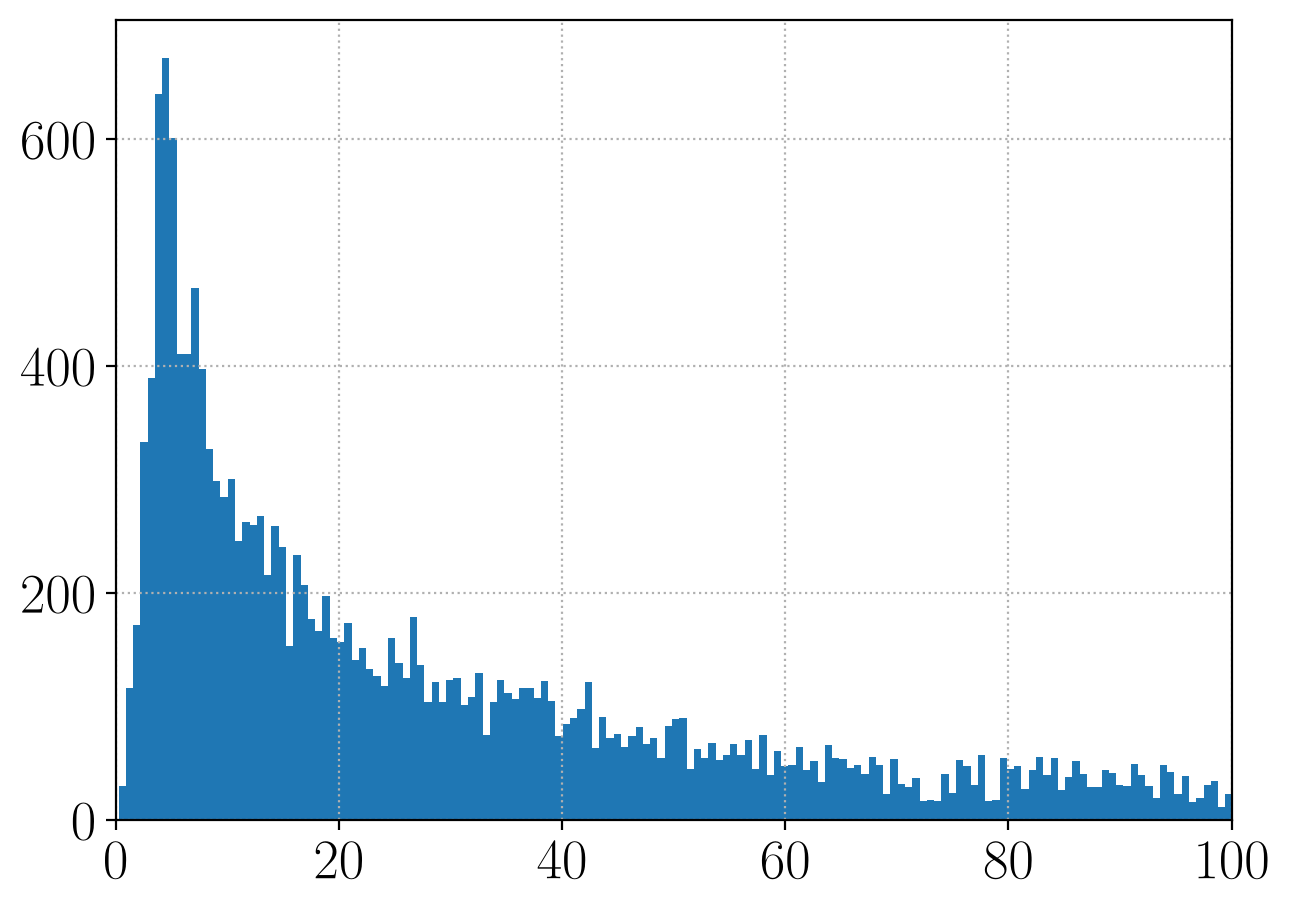

In [15]:
plt.hist(samples[:,3],bins=1000)
plt.xlim(0,100)

In [16]:
samples[:,3] = np.log10(samples[:,3])  # log t_merger

## Per-file log merger-time histograms

Plot one `log10(t_merger / yr)` histogram per sample file on the same axes.

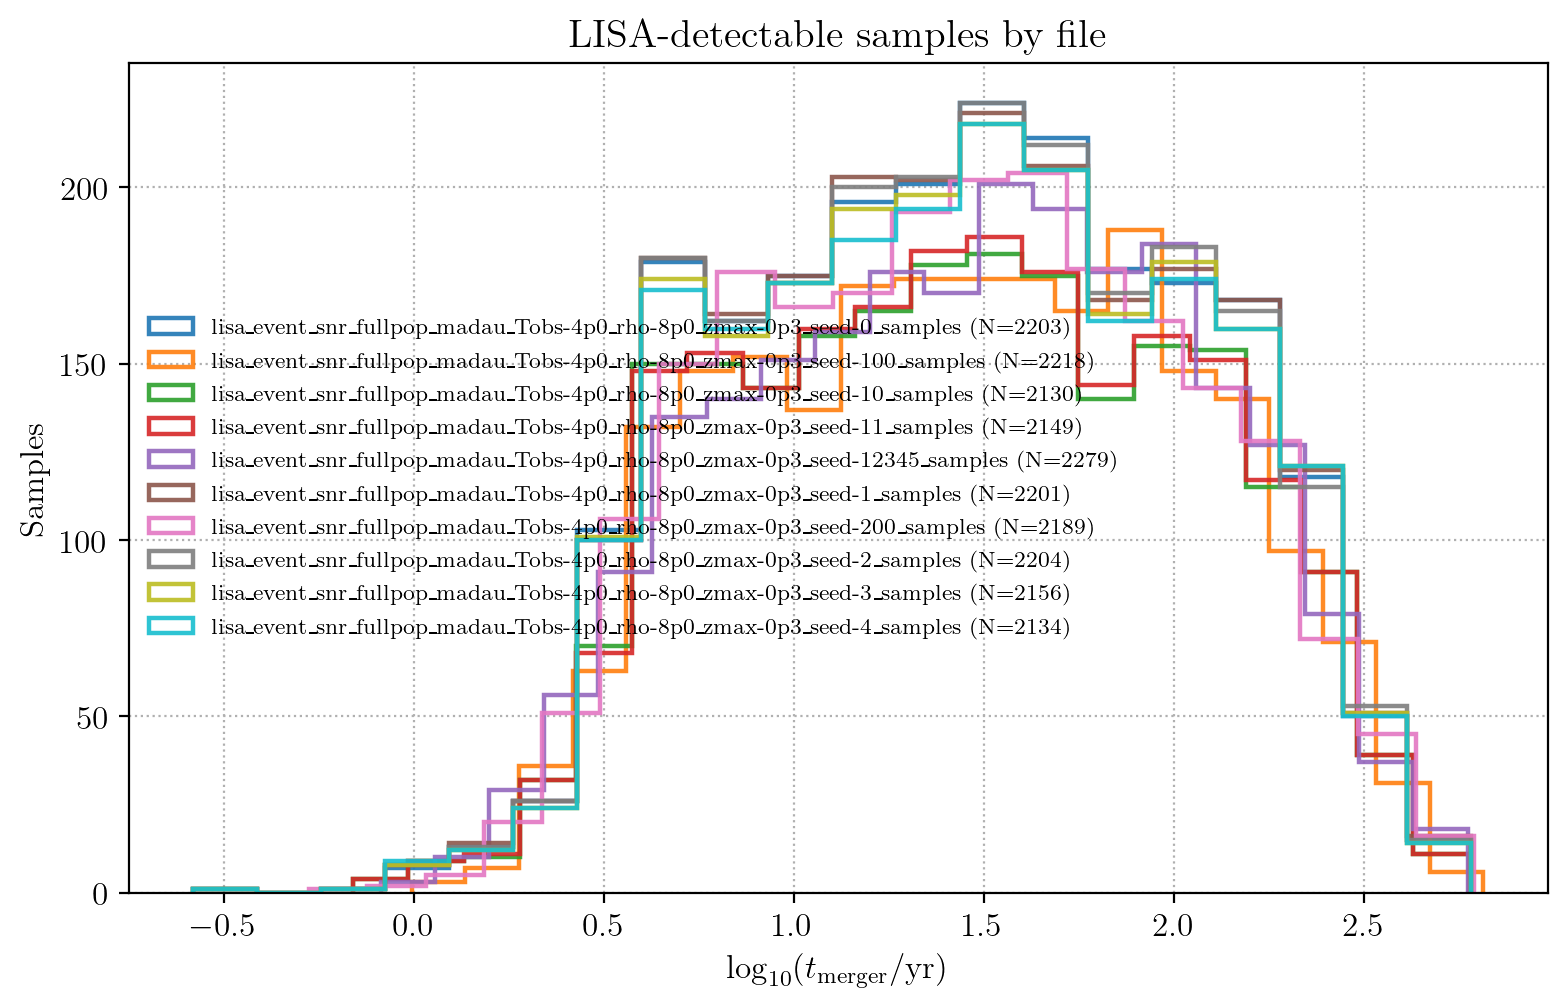

In [ ]:
hist_out = Path('../plots') / f'{sample_dir.name}_log_t_merger_hist_by_file.png'

fig_hist, ax = plt.subplots(figsize=(8.0, 5.2))
for path in sample_files:
    file_samples = load_samples(path)
    if len(file_samples) == 0:
        continue
    log_t_merger = np.log10(file_samples[:, 3])
    ax.hist(
        log_t_merger,
        bins=20,
        histtype='step',
        linewidth=1.6,
        alpha=0.9,
        label=f'{path.stem} (N={len(file_samples)})',
    )

ax.set_xlabel(r'$\log_{10}(t_\mathrm{merger}/\mathrm{yr})$')
ax.set_ylabel('Samples')
ax.set_title('LISA-detectable samples by file')
ax.grid(True, linestyle=':')
ax.legend(fontsize=8, frameon=False)
fig_hist.tight_layout()
plt.show()


In [ ]:
hist_out.parent.mkdir(parents=True, exist_ok=True)
fig_hist.savefig(hist_out, dpi=220, bbox_inches='tight')
print(f'Saved per-file log t_merger histogram to {hist_out}')


Saved per-file log t_merger histogram to ../plots/lisa_event_count_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples_log_t_merger_hist_by_file.png


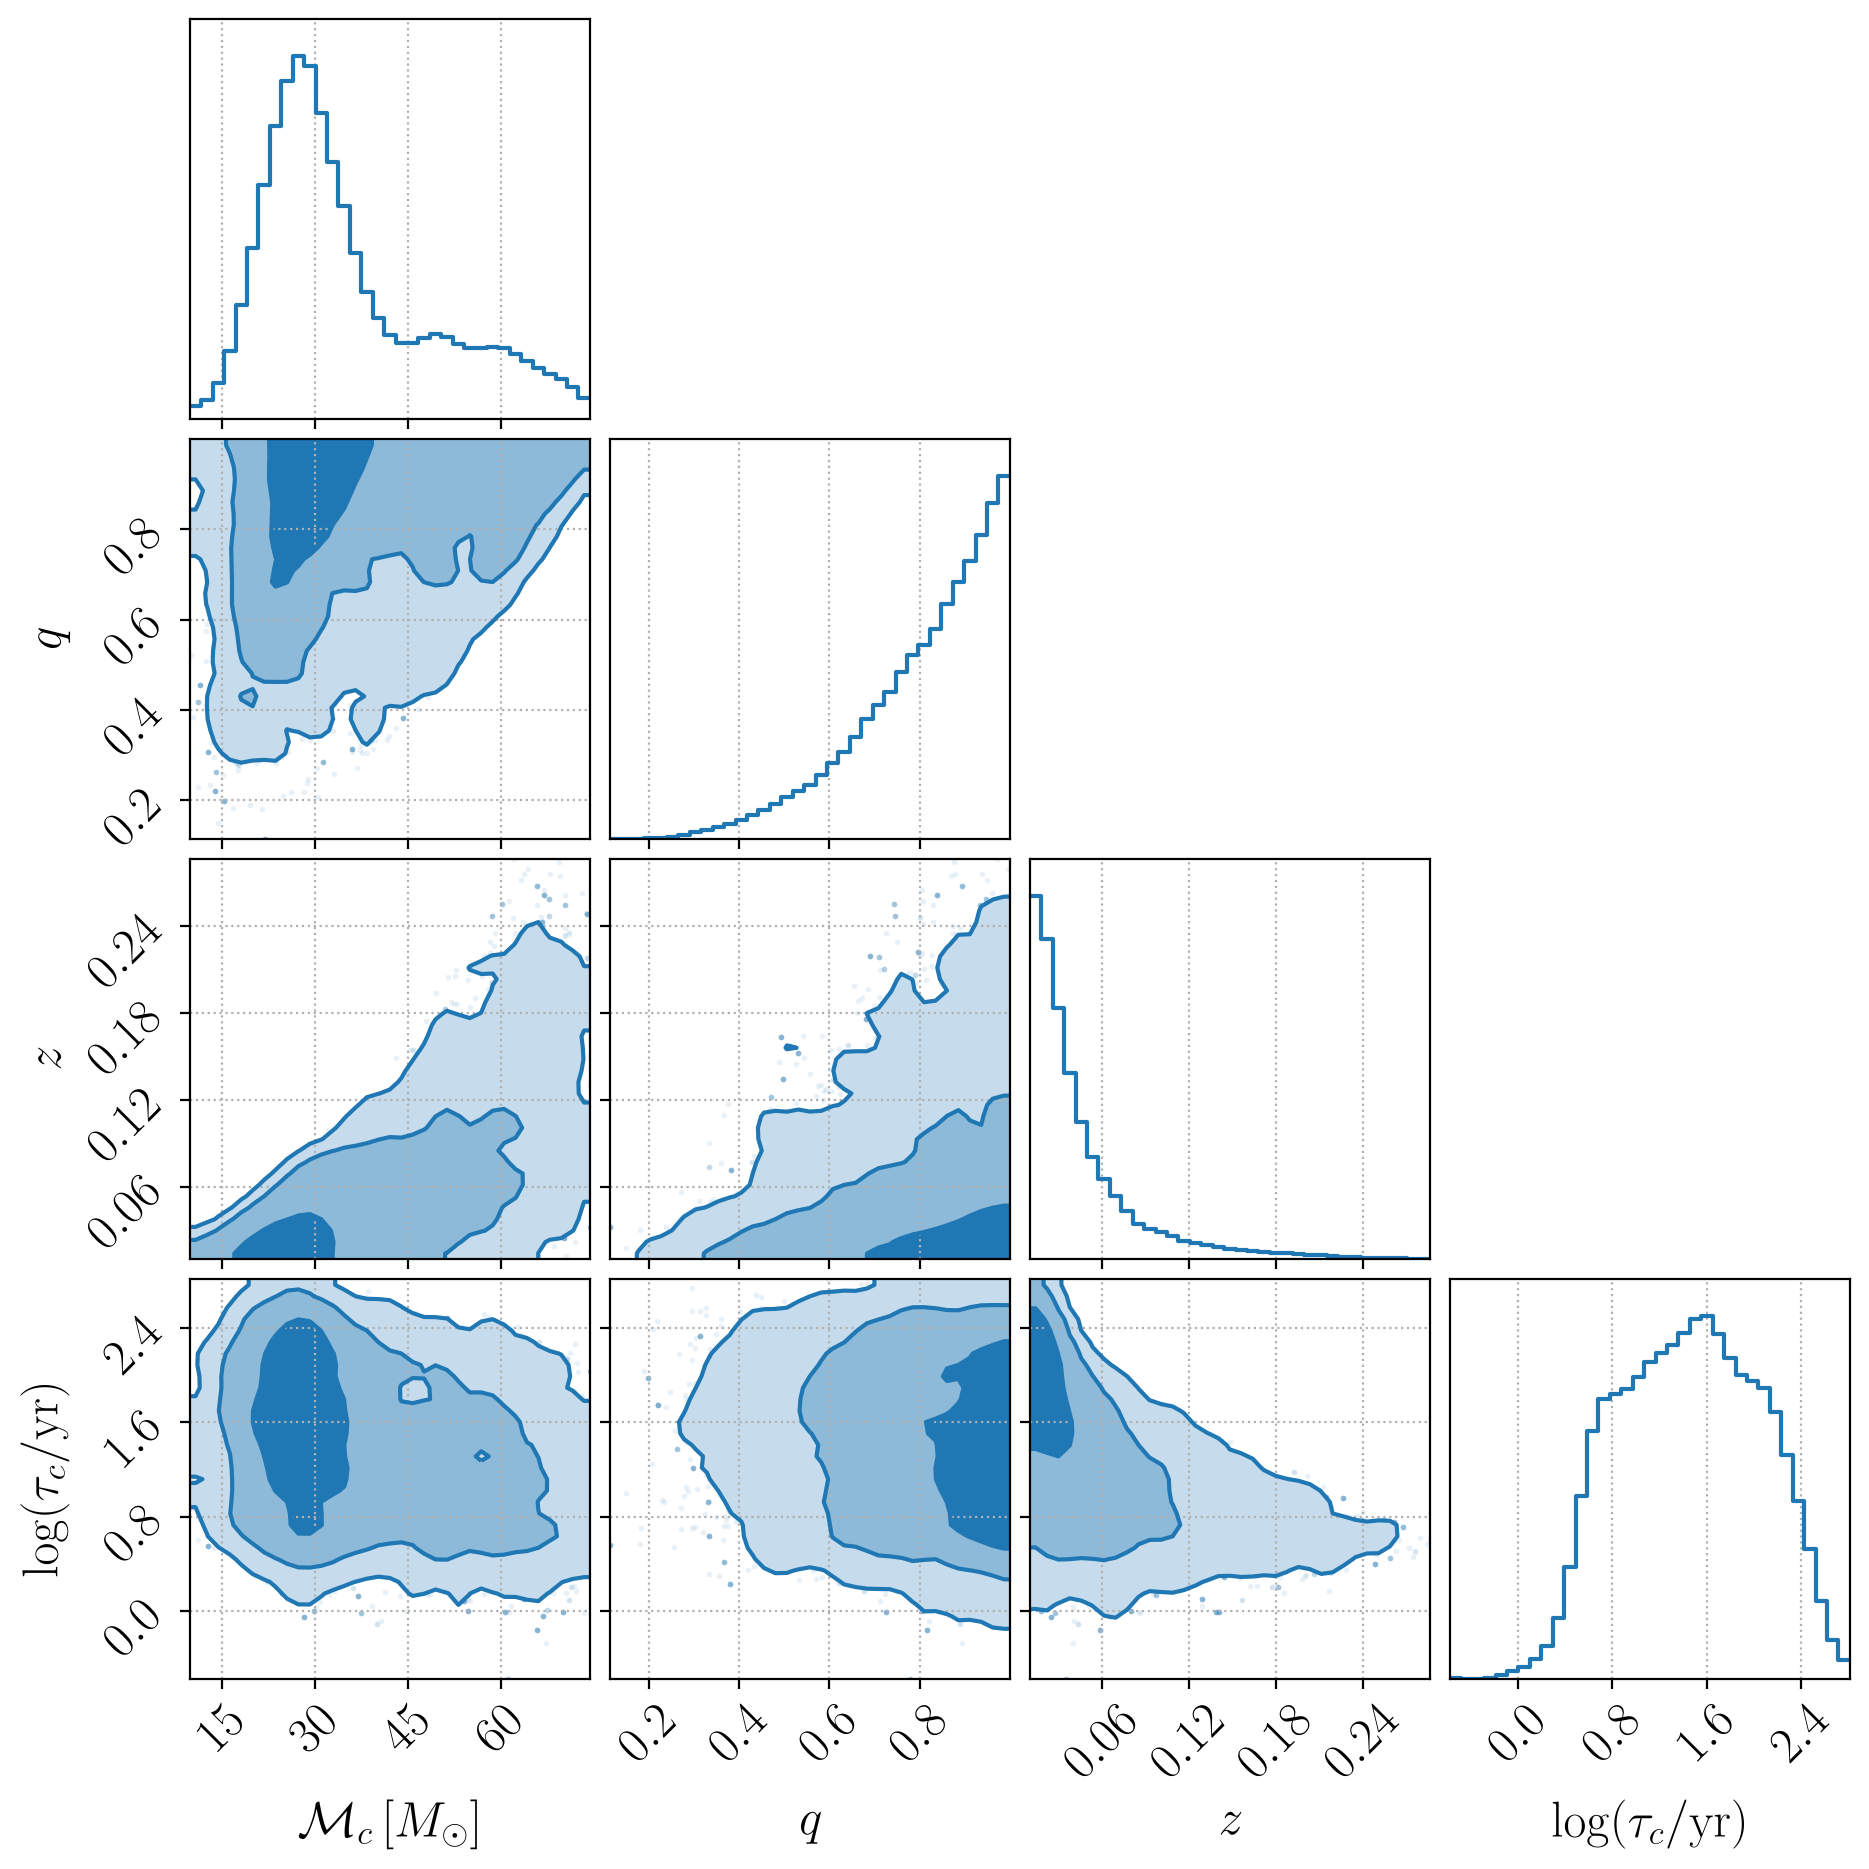

In [22]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
# figure.suptitle('LISA-detectable FullPop+Madau samples', y=0.995)
plt.show()

In [23]:
out.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(out, dpi=220, bbox_inches='tight')
print(f'Saved corner plot to {out}')


Saved corner plot to ../plots/lisa_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p3_samples_corner.png


In [17]:
samples_taiji, sample_files, sample_counts_taiji = load_sample_directory(Path('taiji_event_snr'), sample_pattern)
samples_tianqin, sample_files, sample_counts_tianqin = load_sample_directory(Path('tianqin_event_snr'), sample_pattern)

samples_taiji[:,3] = np.log10(samples_taiji[:,3])  # log t_merger
samples_tianqin[:,3] = np.log10(samples_tianqin[:,3])  # log t_merger

print(sample_counts_taiji,sample_counts_tianqin)

[763, 813, 817, 750, 761, 756, 742, 738, 725, 723, 734, 741] [1327, 1407, 1354, 1309, 1332, 1324, 1296, 1292, 1275, 1280, 1294, 1304]


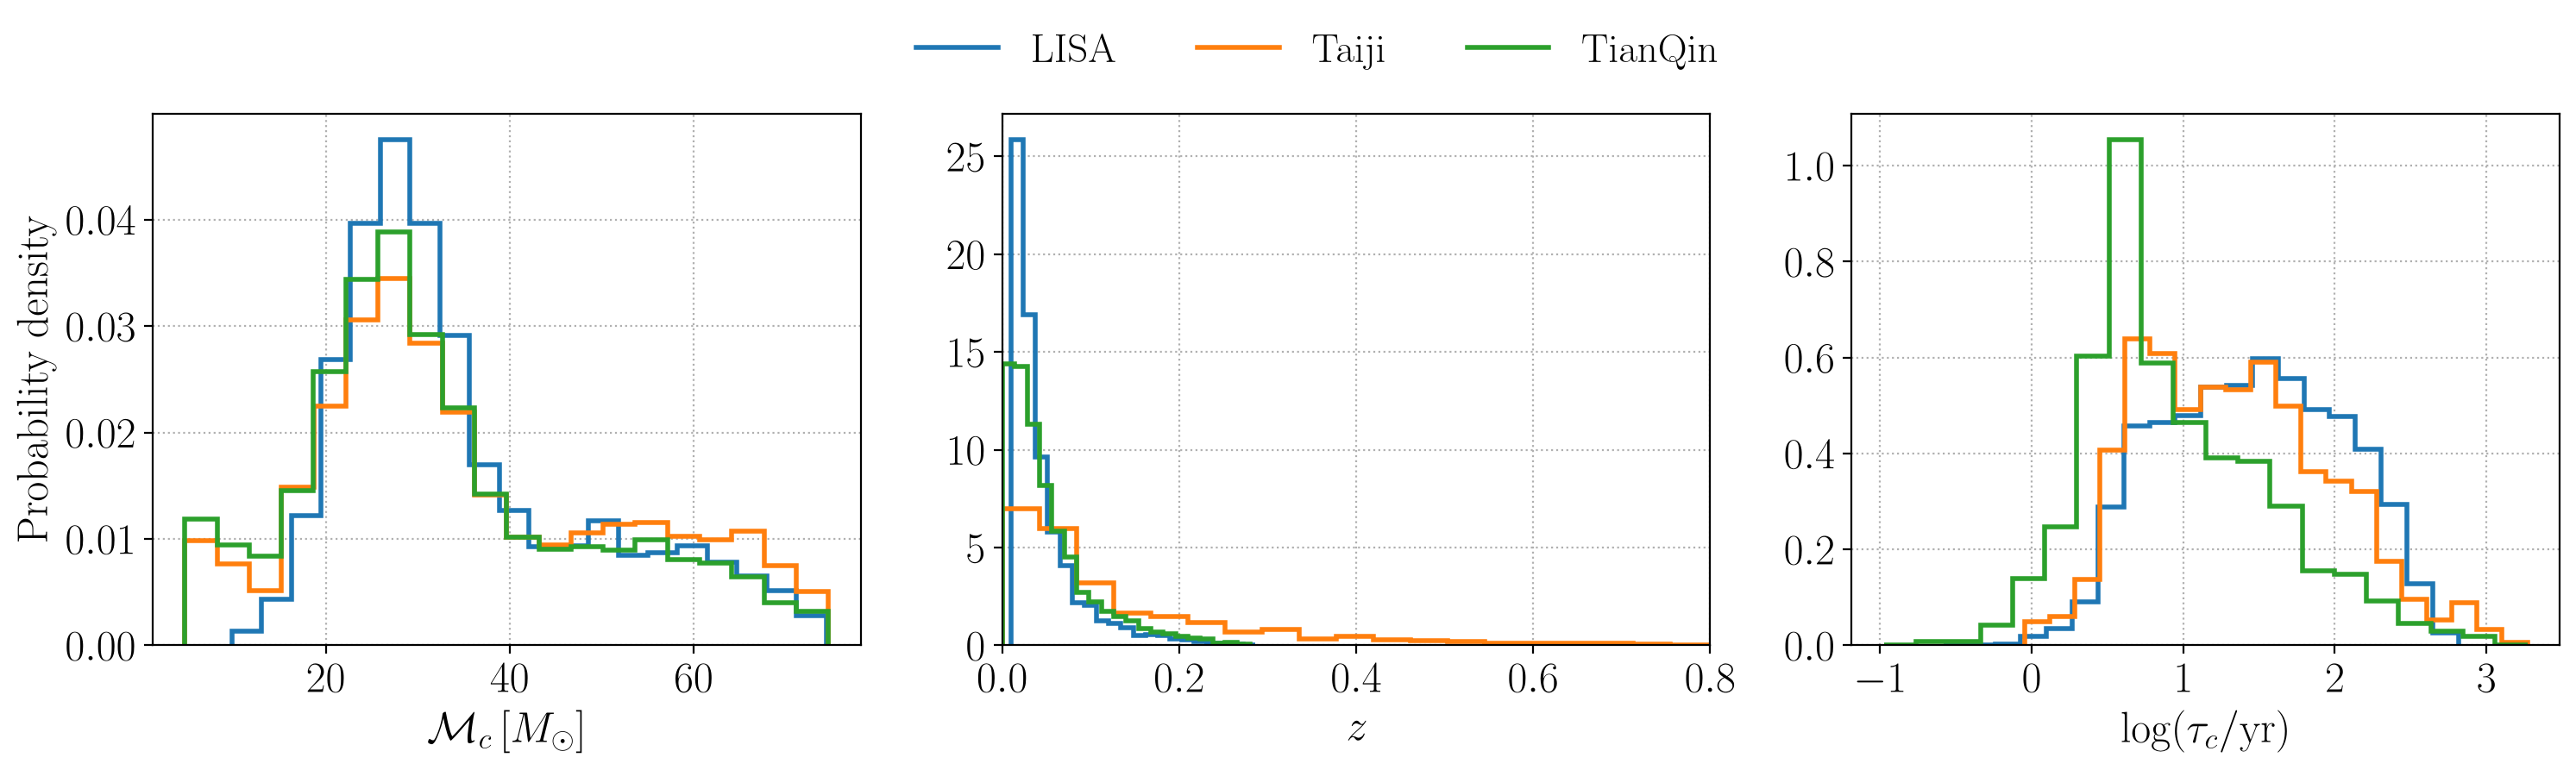

In [23]:
from matplotlib.lines import Line2D
plt.rcParams.update({"font.size": 18})
bins = 20

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(samples[:,0],bins=bins,histtype='step',density=True,lw=2,label='LISA')
ax[0].hist(samples_taiji[:,0],bins=bins,histtype='step',density=True,lw=2,label='Taiji')
ax[0].hist(samples_tianqin[:,0],bins=bins,histtype='step',density=True,lw=2,label='TianQin')
ax[0].set_xlabel(r'$\mathcal{M}_c\,[M_\odot]$')
ax[0].set_ylabel('Probability density')

ax[1].hist(samples[:,2],bins=bins,histtype='step',density=True,lw=2,label='LISA')
ax[1].hist(samples_taiji[:,2],bins=bins,histtype='step',density=True,lw=2,label='Taiji')
ax[1].hist(samples_tianqin[:,2],bins=bins,histtype='step',density=True,lw=2,label='TianQin')
ax[1].set_xlabel(r'$z$')
ax[1].set_xlim(0,0.8)

ax[2].hist(samples[:,3],bins=bins,histtype='step',density=True,lw=2,label='LISA')
ax[2].hist(samples_taiji[:,3],bins=bins,histtype='step',density=True,lw=2,label='Taiji')
ax[2].hist(samples_tianqin[:,3],bins=bins,histtype='step',density=True,lw=2,label='TianQin')
ax[2].set_xlabel(r'$\log (\tau_c/\mathrm{yr})$')

legend_elements = [Line2D([0], [0], color='C0', lw=2, label='LISA'),
                   Line2D([0], [0], color='C1', lw=2, label='Taiji'),
                   Line2D([0], [0], color='C2', lw=2, label='TianQin')]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=17, frameon=False, bbox_to_anchor=(0.5, 1.05))
plt.savefig('../plots/lisa_taiji_tianqin_comparison.png', dpi=600, bbox_inches='tight')

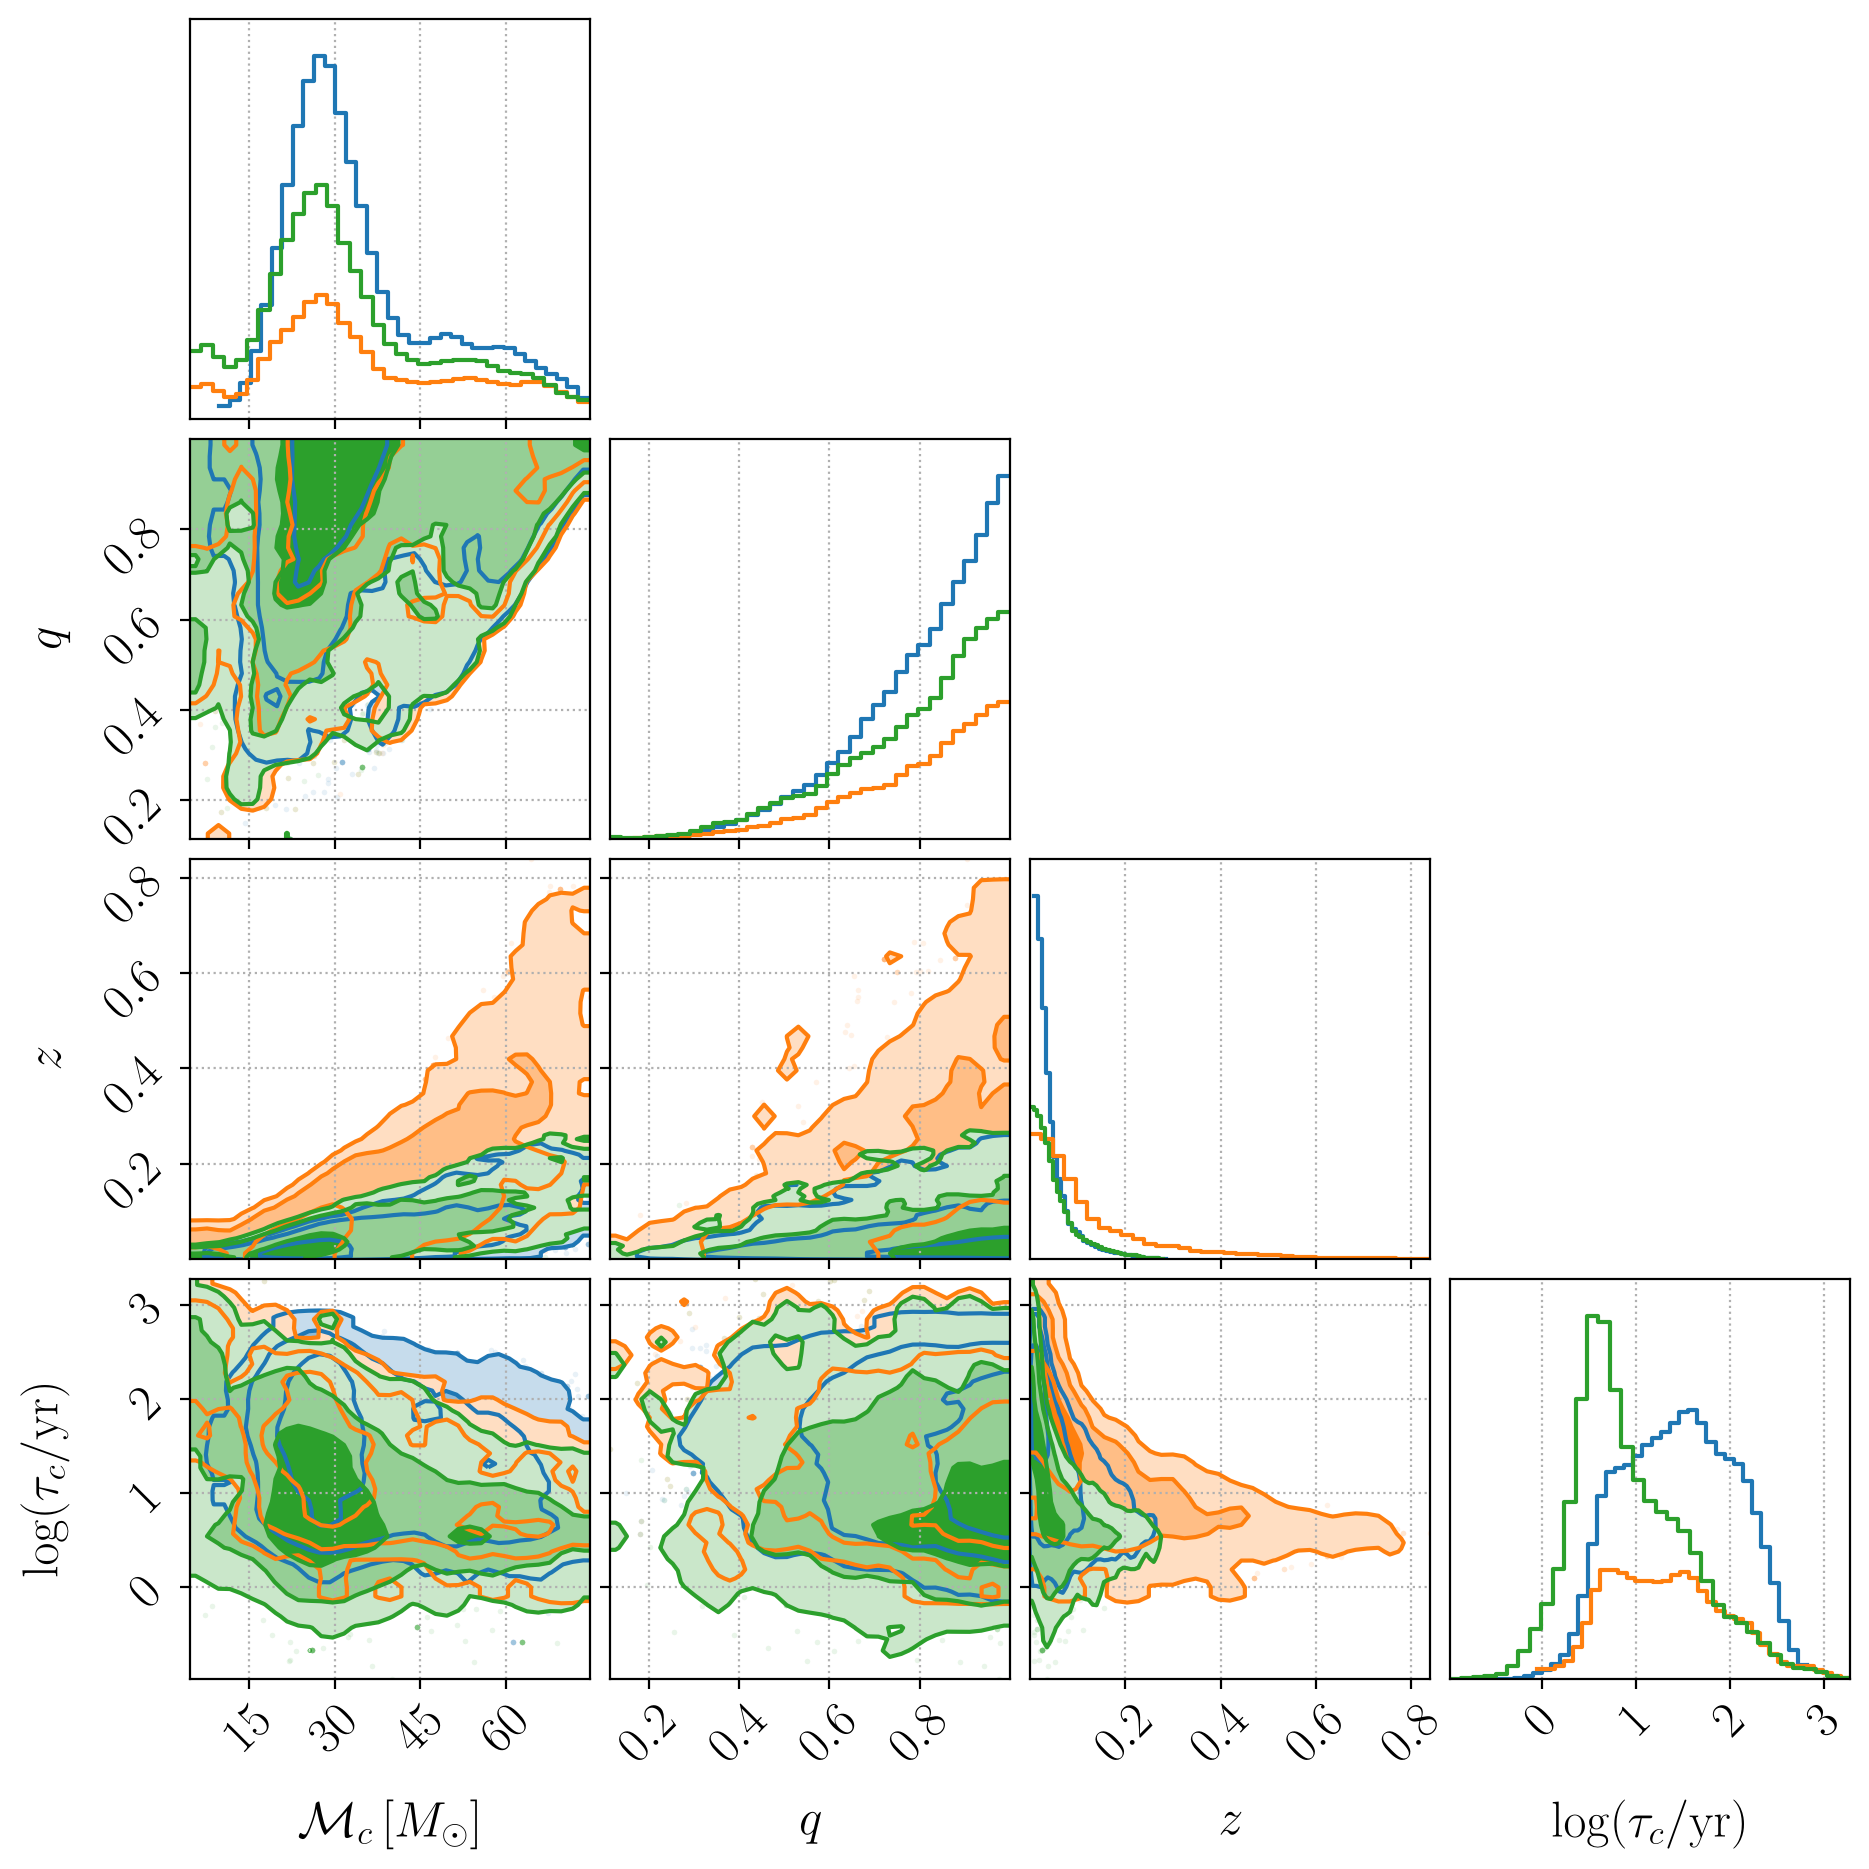

In [10]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989)
)
corner.corner(
    samples_taiji,
    fig=figure,
    labels=labels,
    bins=bins,
    color='C1',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989)
)
corner.corner(
    samples_tianqin,
    fig=figure,
    labels=labels,
    bins=bins,
    color='C2',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989)
)
# figure.suptitle('LISA-detectable FullPop+Madau samples', y=0.995)
plt.show()

In [7]:
taiji_samples = load_samples('taiji_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-1p0_samples.txt')
tianqin_samples = load_samples('tianqin_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-0p5_samples.txt')

taiji_samples[:,3] = np.log10(taiji_samples[:,3])  # log t_merger
tianqin_samples[:,3] = np.log10(tianqin_samples[:,3])  # log t_merger

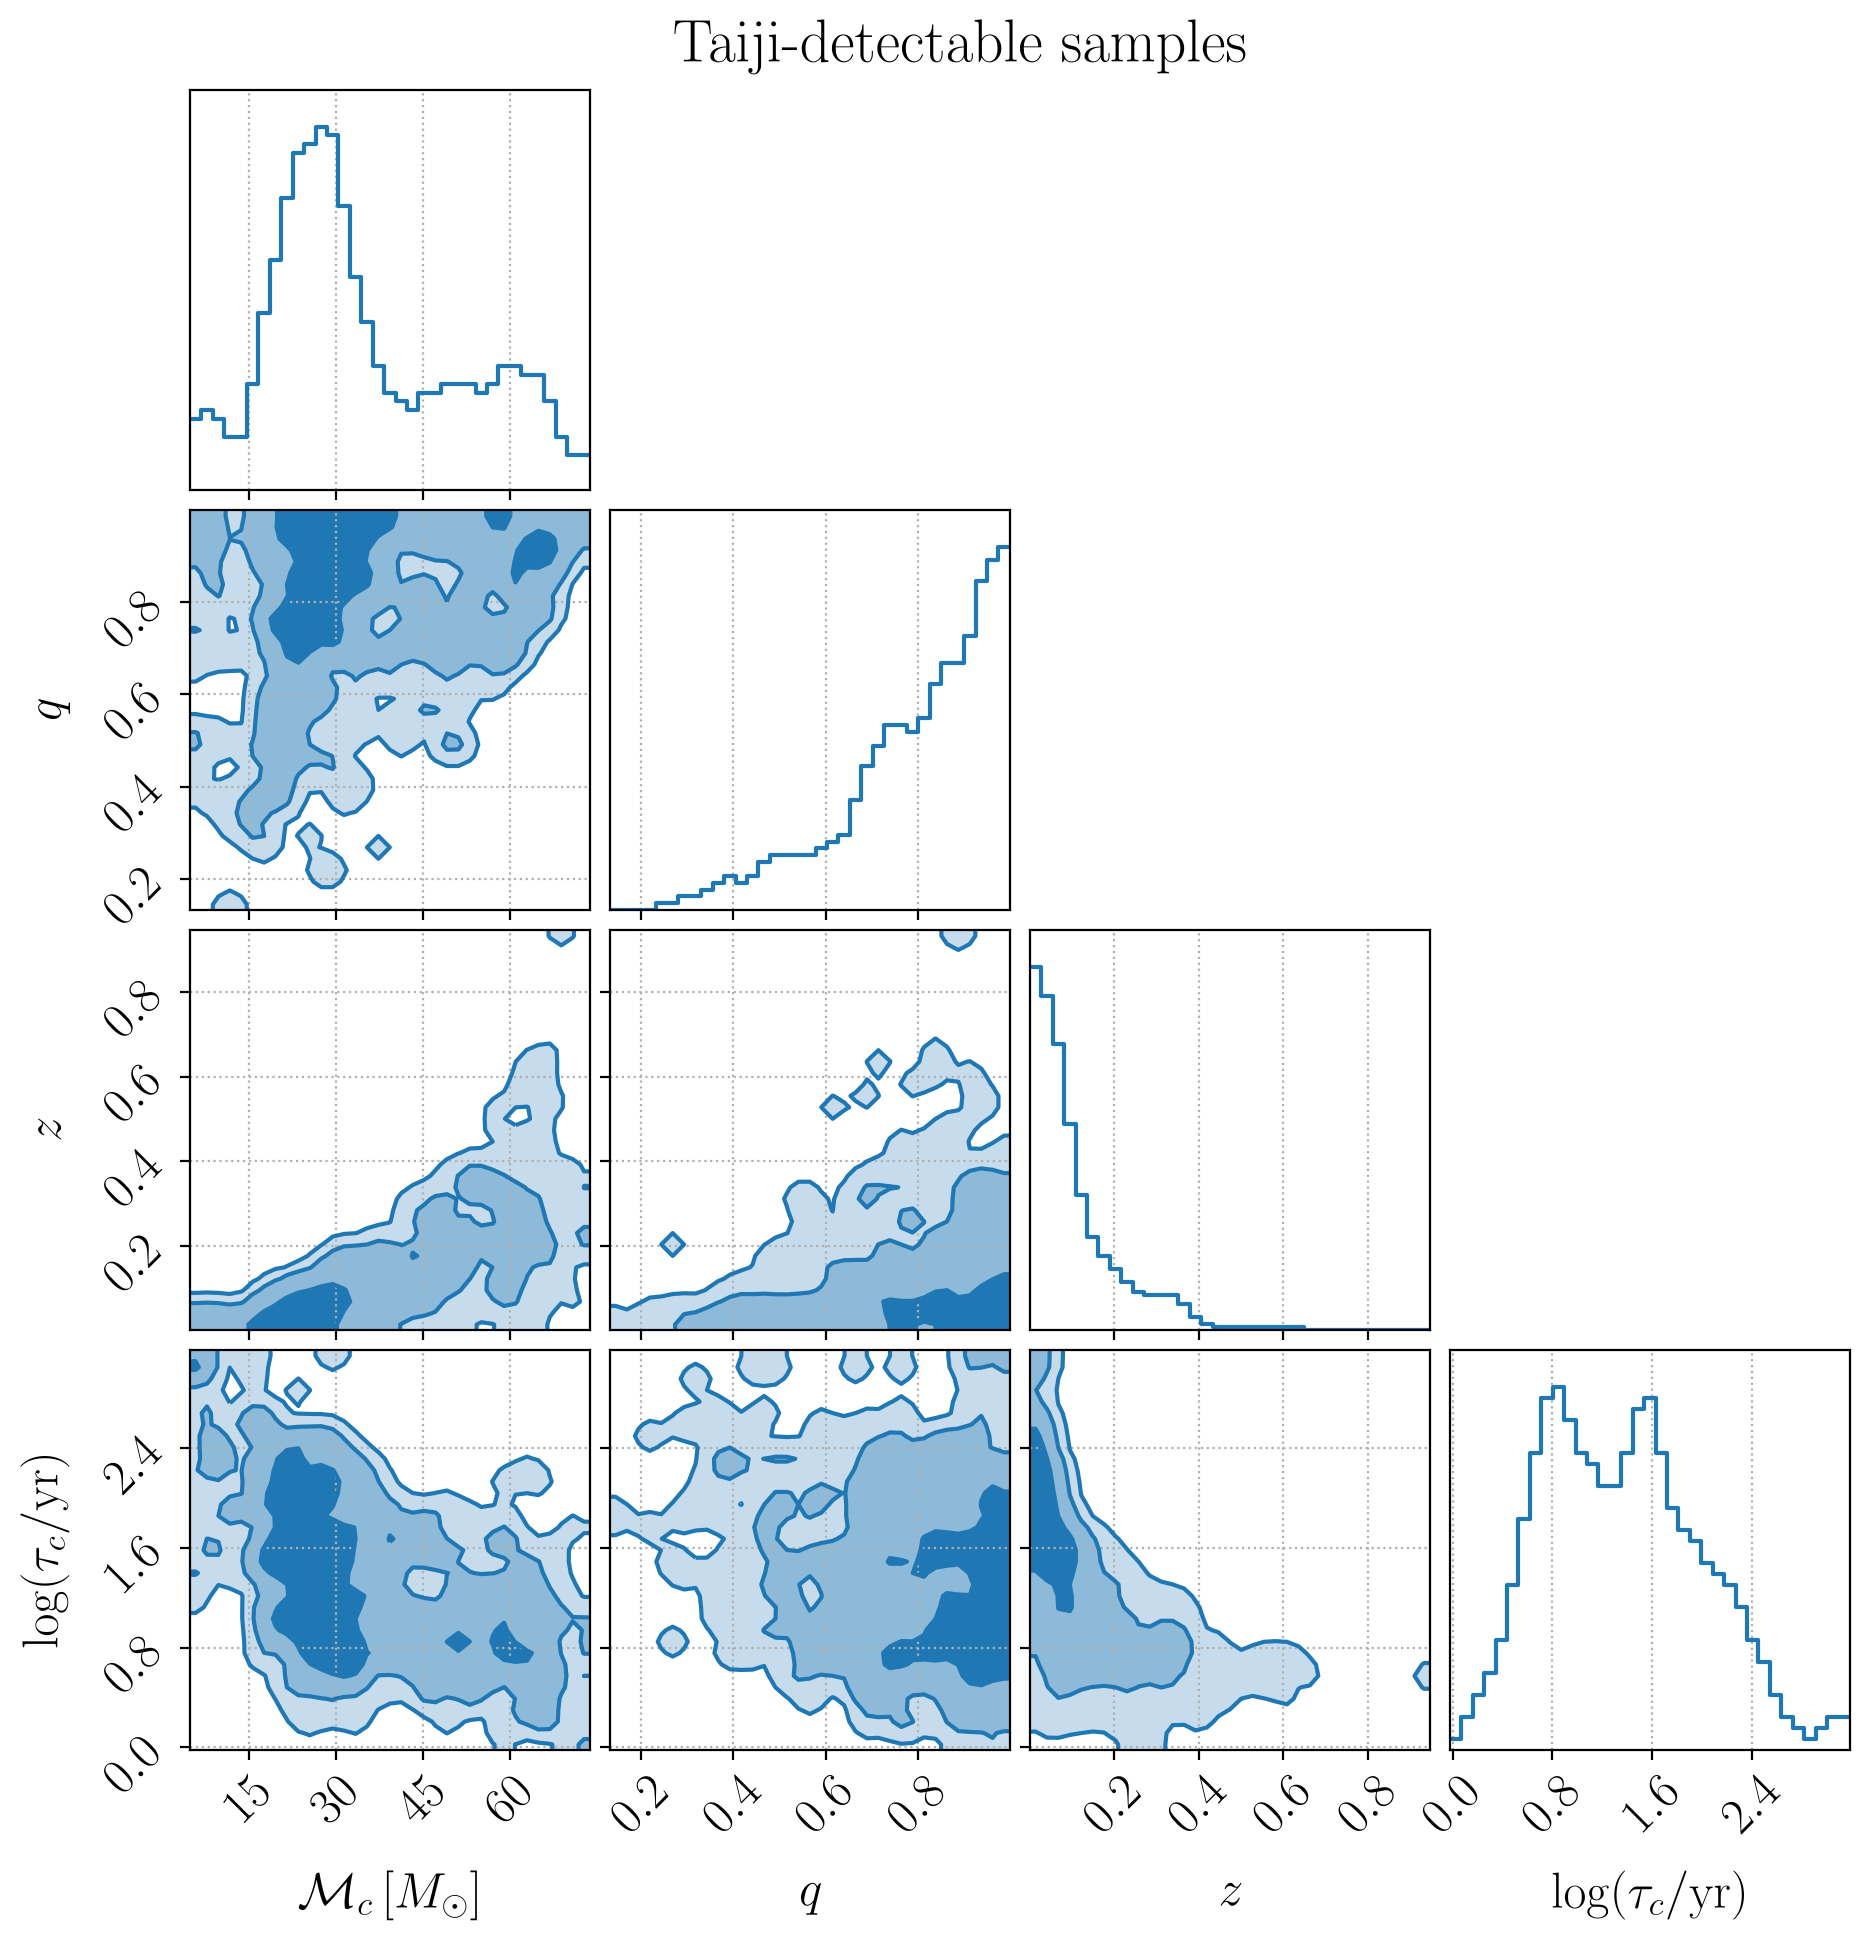

In [8]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    taiji_samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
figure.suptitle('Taiji-detectable samples', y=0.995)
plt.show()

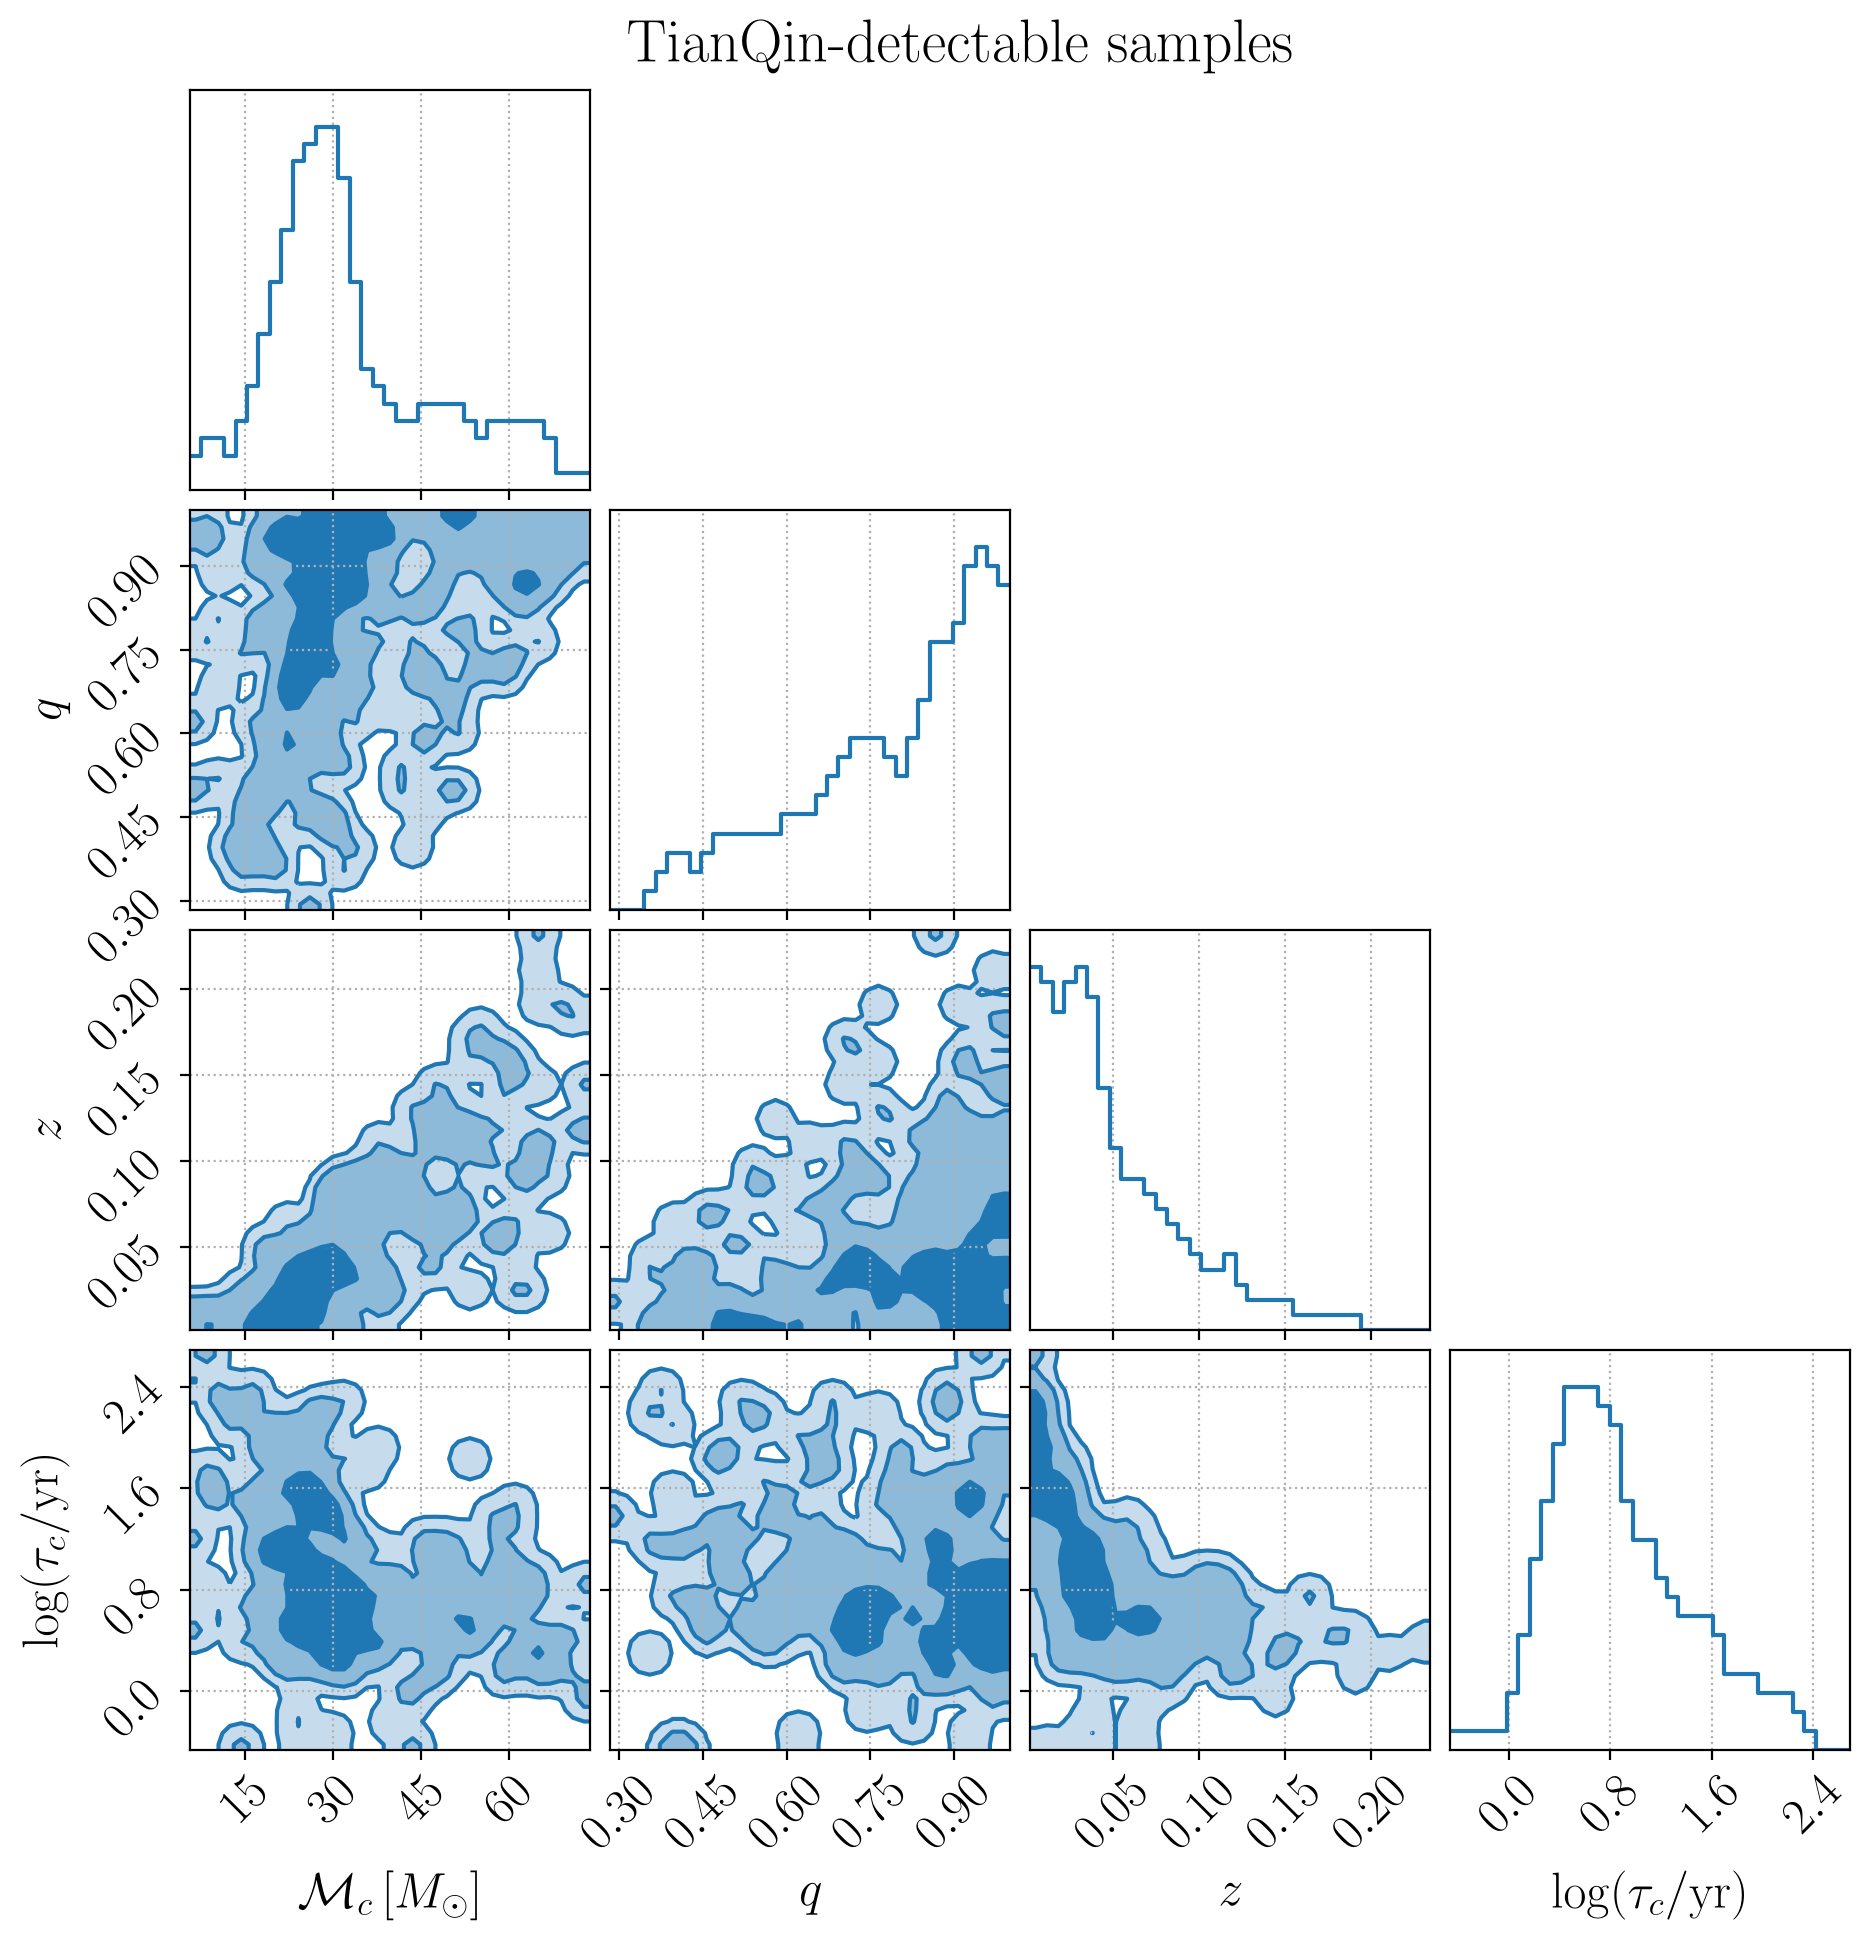

In [9]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    tianqin_samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
figure.suptitle('TianQin-detectable samples', y=0.995)
plt.show()

In [6]:
# lgwa_samples = load_samples('lgwa_event_snr/old/lgwa_event_snr_fullpop_madau_Tobs-10p0_rho-8p0_zmax-1p0_samples.txt')
lgwa_samples = load_samples('lgwa_event_snr/lgwa_event_snr_fullpop_madau_Tobs-10p0_rho-8p0_zmax-1p0_samples.txt')
# lgwa_samples, sample_files_lgwa, sample_counts_lgwa = load_sample_directory(Path('lgwa_event_snr'), sample_pattern='')
# lgwa_samples_full = load_samples('lgwa_event_snr/lgwa_event_snr_fullpop_madau_Tobs-10p0_rho-8p0_zmax-0p7_samples_full.txt')

lgwa_samples[:,3] = np.log10(lgwa_samples[:,3])  # log t_merger
# lgwa_samples_full[:,3] = np.log10(lgwa_samples_full[:,3])  # log t_merger
# lgwa_samples_full[:,0] = np.log10(lgwa_samples_full[:,0])  # log t_merger

In [14]:
amigo_samples = load_samples('amigo_event_snr/amigo_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-1p0_seed-12345_samples.txt')
amigo_5_samples = load_samples('amigo_event_snr/amigo-5_event_snr_fullpop_madau_Tobs-4p0_rho-8p0_zmax-2p0_seed-12345_samples.txt')

amigo_samples[:,3] = np.log10(amigo_samples[:,3])  # log t_merger
amigo_5_samples[:,3] = np.log10(amigo_5_samples[:,3])  # log t_merger

In [20]:
len(amigo_samples[:,3]), len(amigo_5_samples[:,3])

(80099, 64945)

In [10]:
len(lgwa_samples[:,3]),len(lgwa_samples_full[:,0]),len(amigo_samples[:,3])

(141982, 1848, 80099)

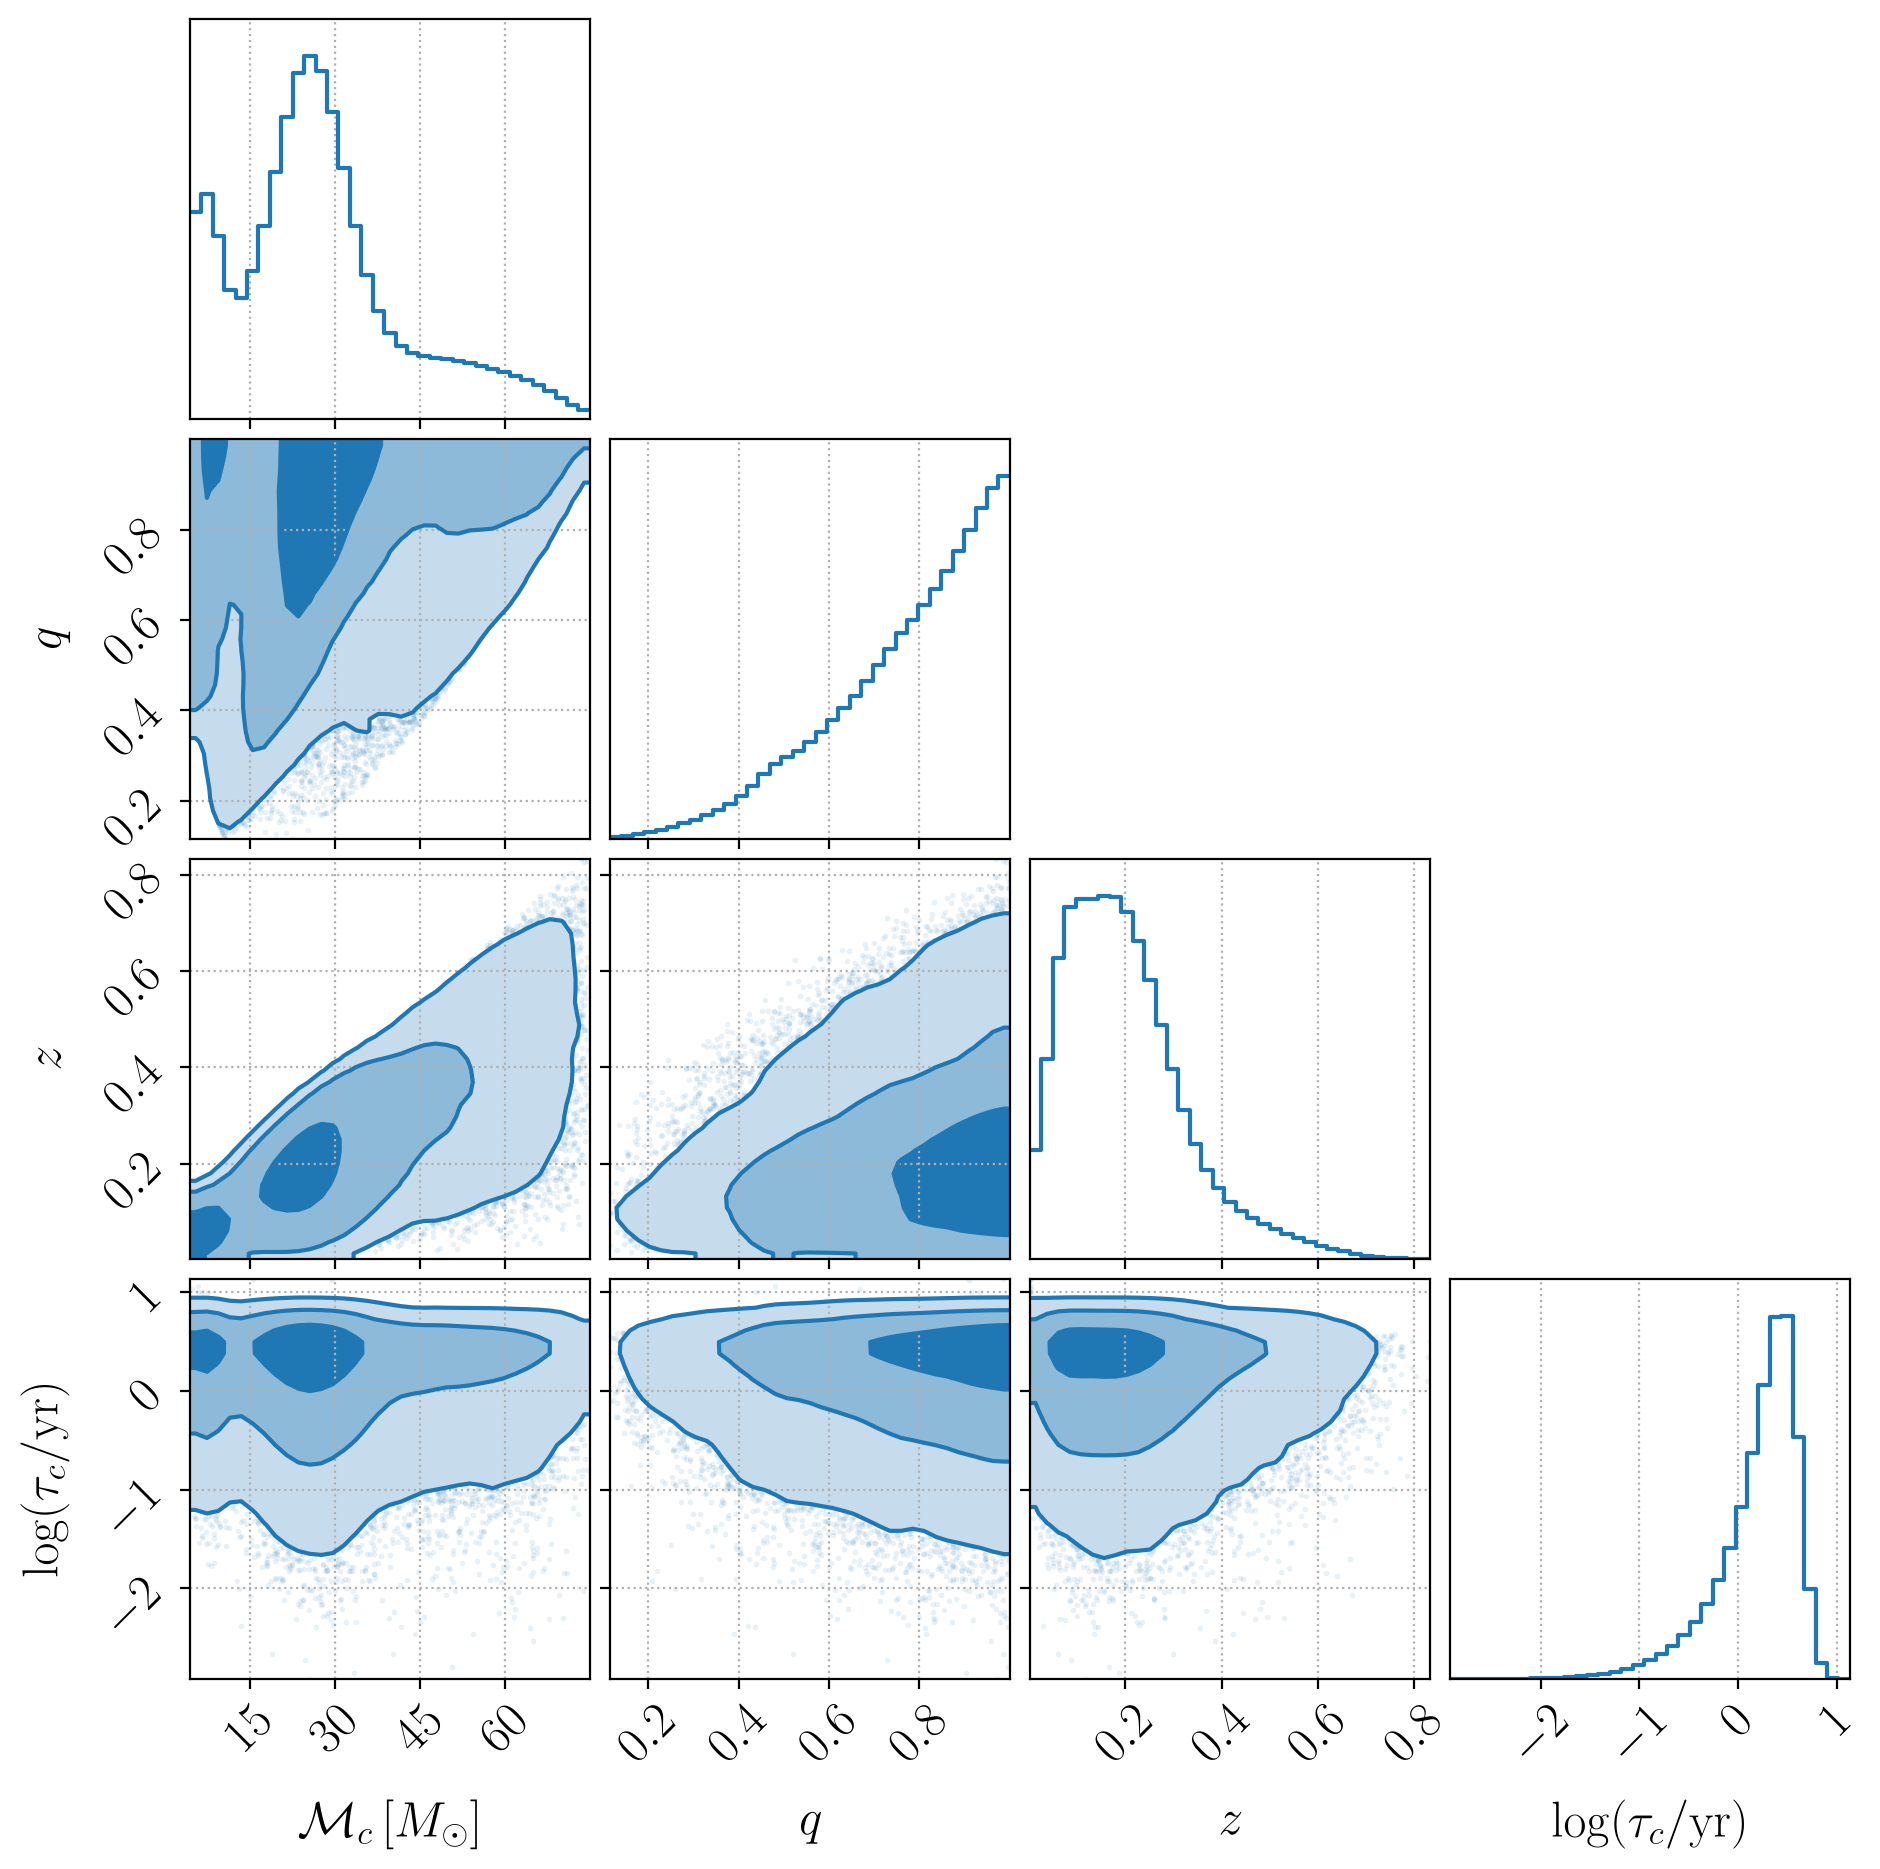

In [23]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    amigo_samples,
    labels=labels,
    bins=35,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)

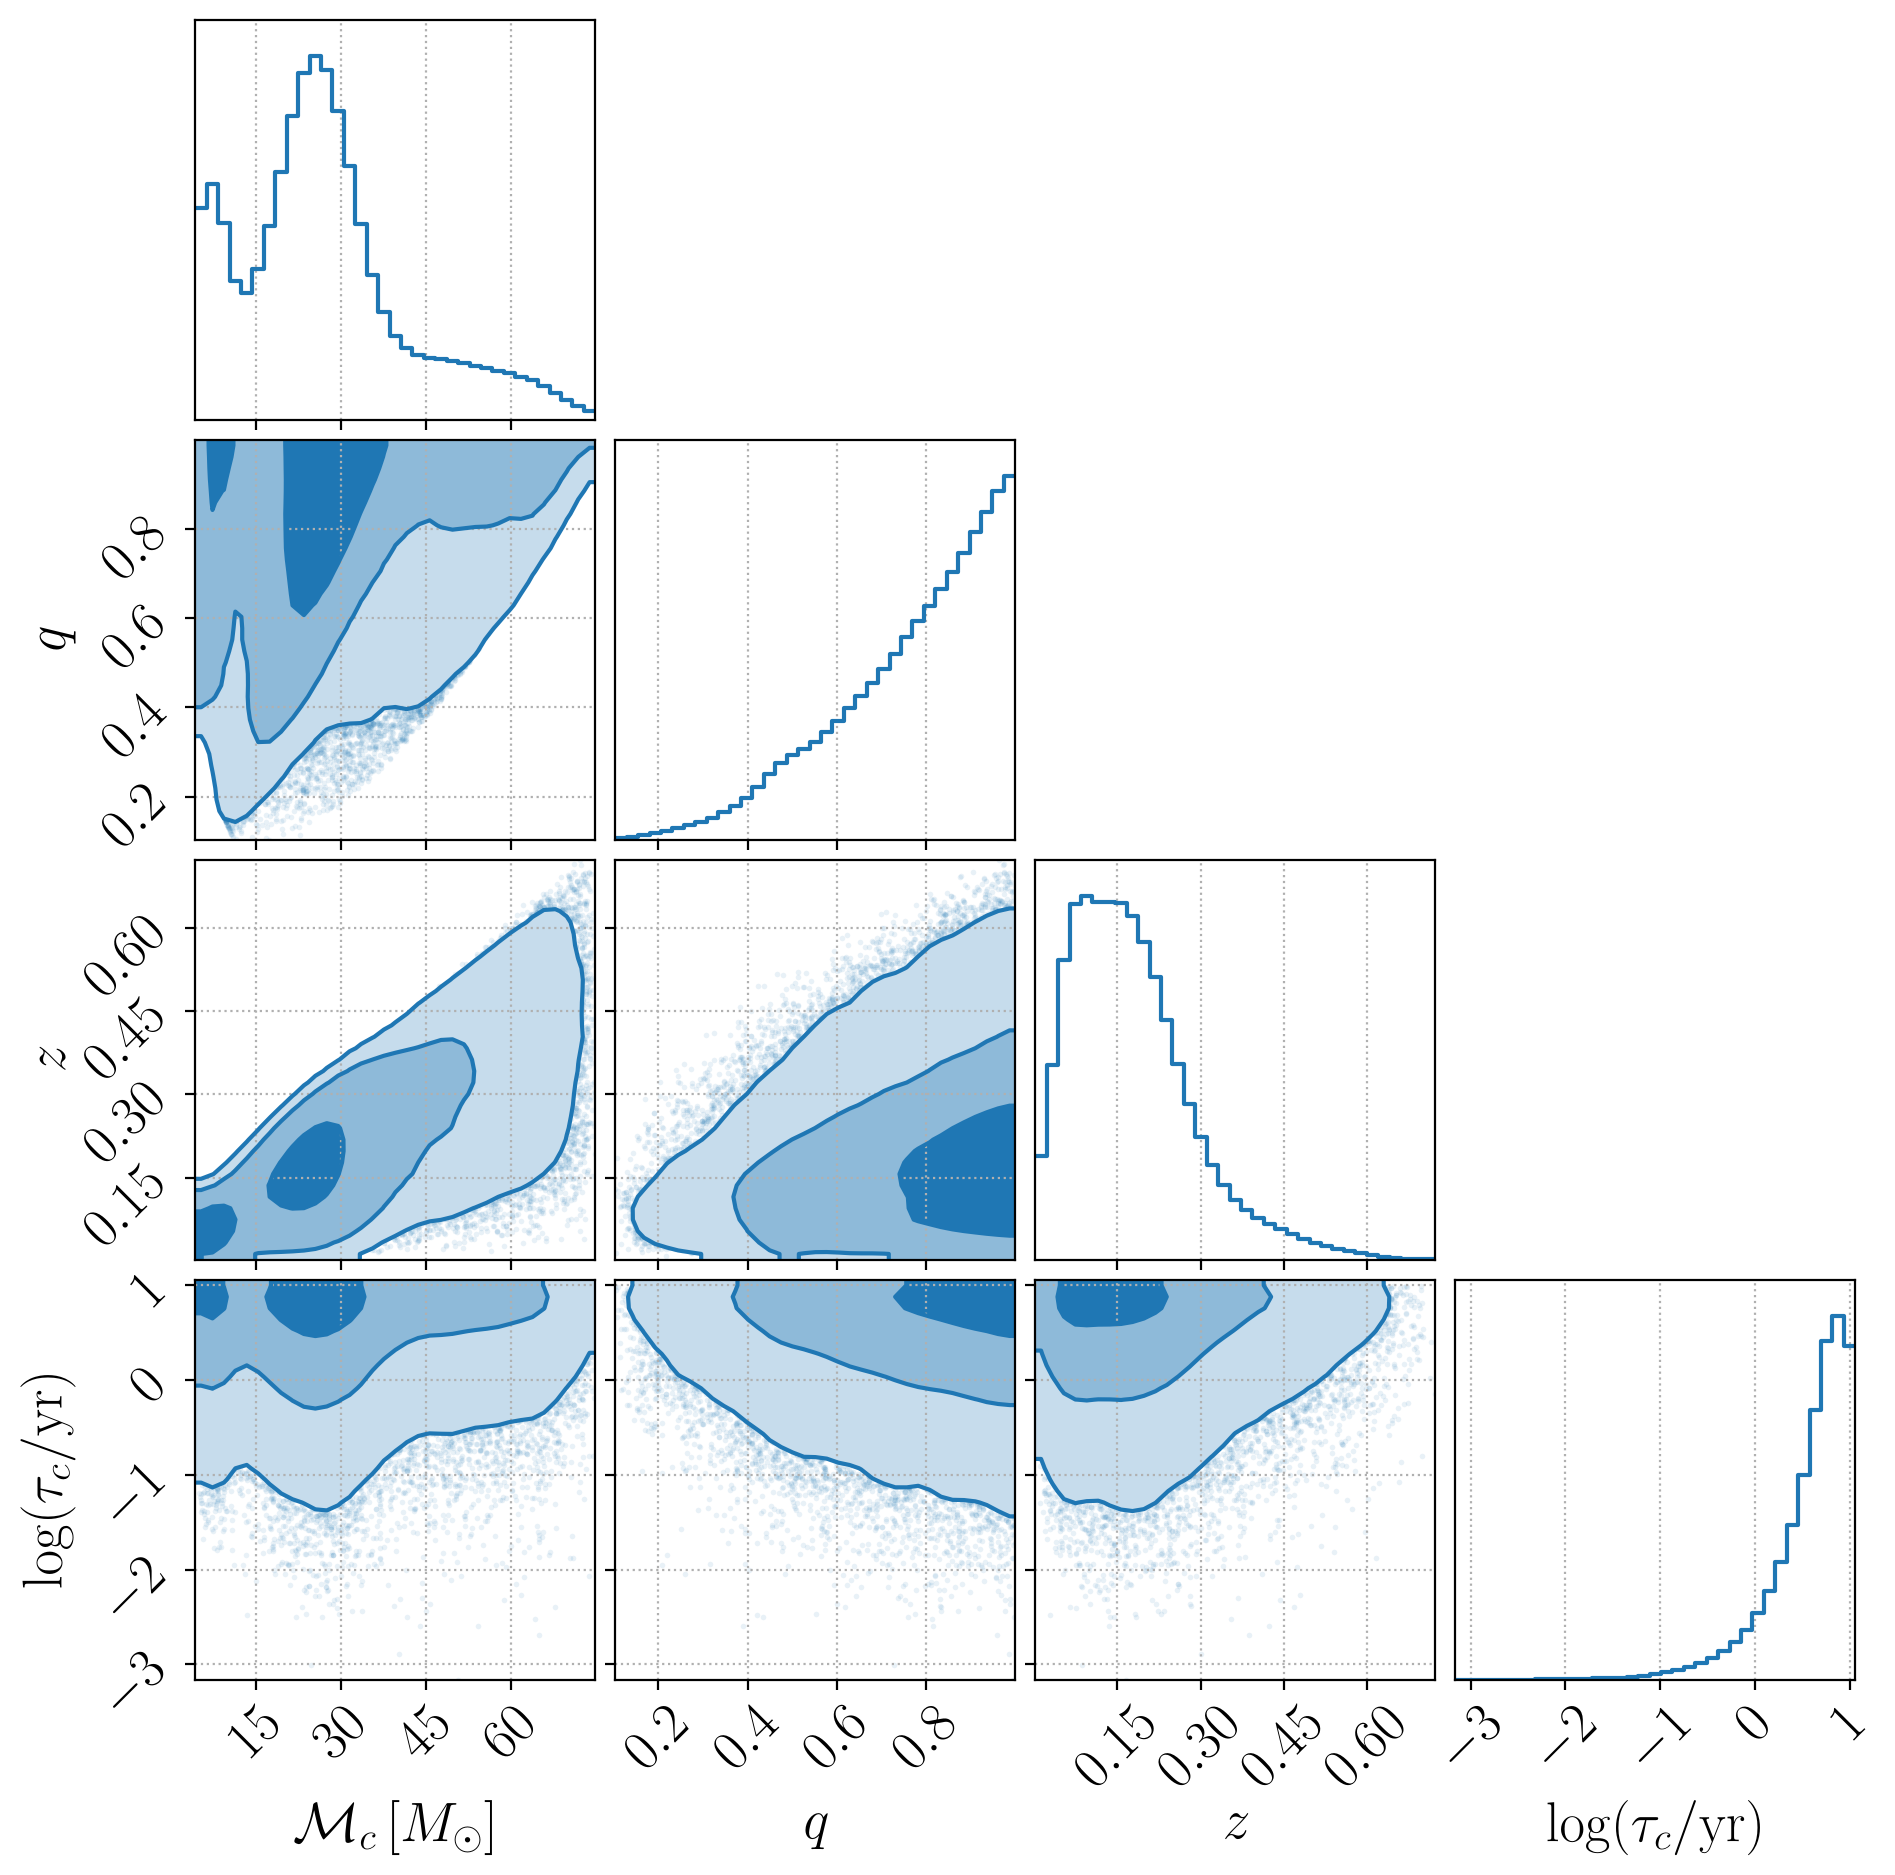

In [24]:
plt.rcParams.update({"font.size": 20})

labels = [
    r'$\mathcal{M}_c\,[M_\odot]$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    lgwa_samples,
    labels=labels,
    bins=35,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
# figure.suptitle('LGWA-detectable samples', y=0.995)
figure.savefig('../plots/lgwa_event_count_samples_corner.png', dpi=600, bbox_inches='tight')
plt.show()

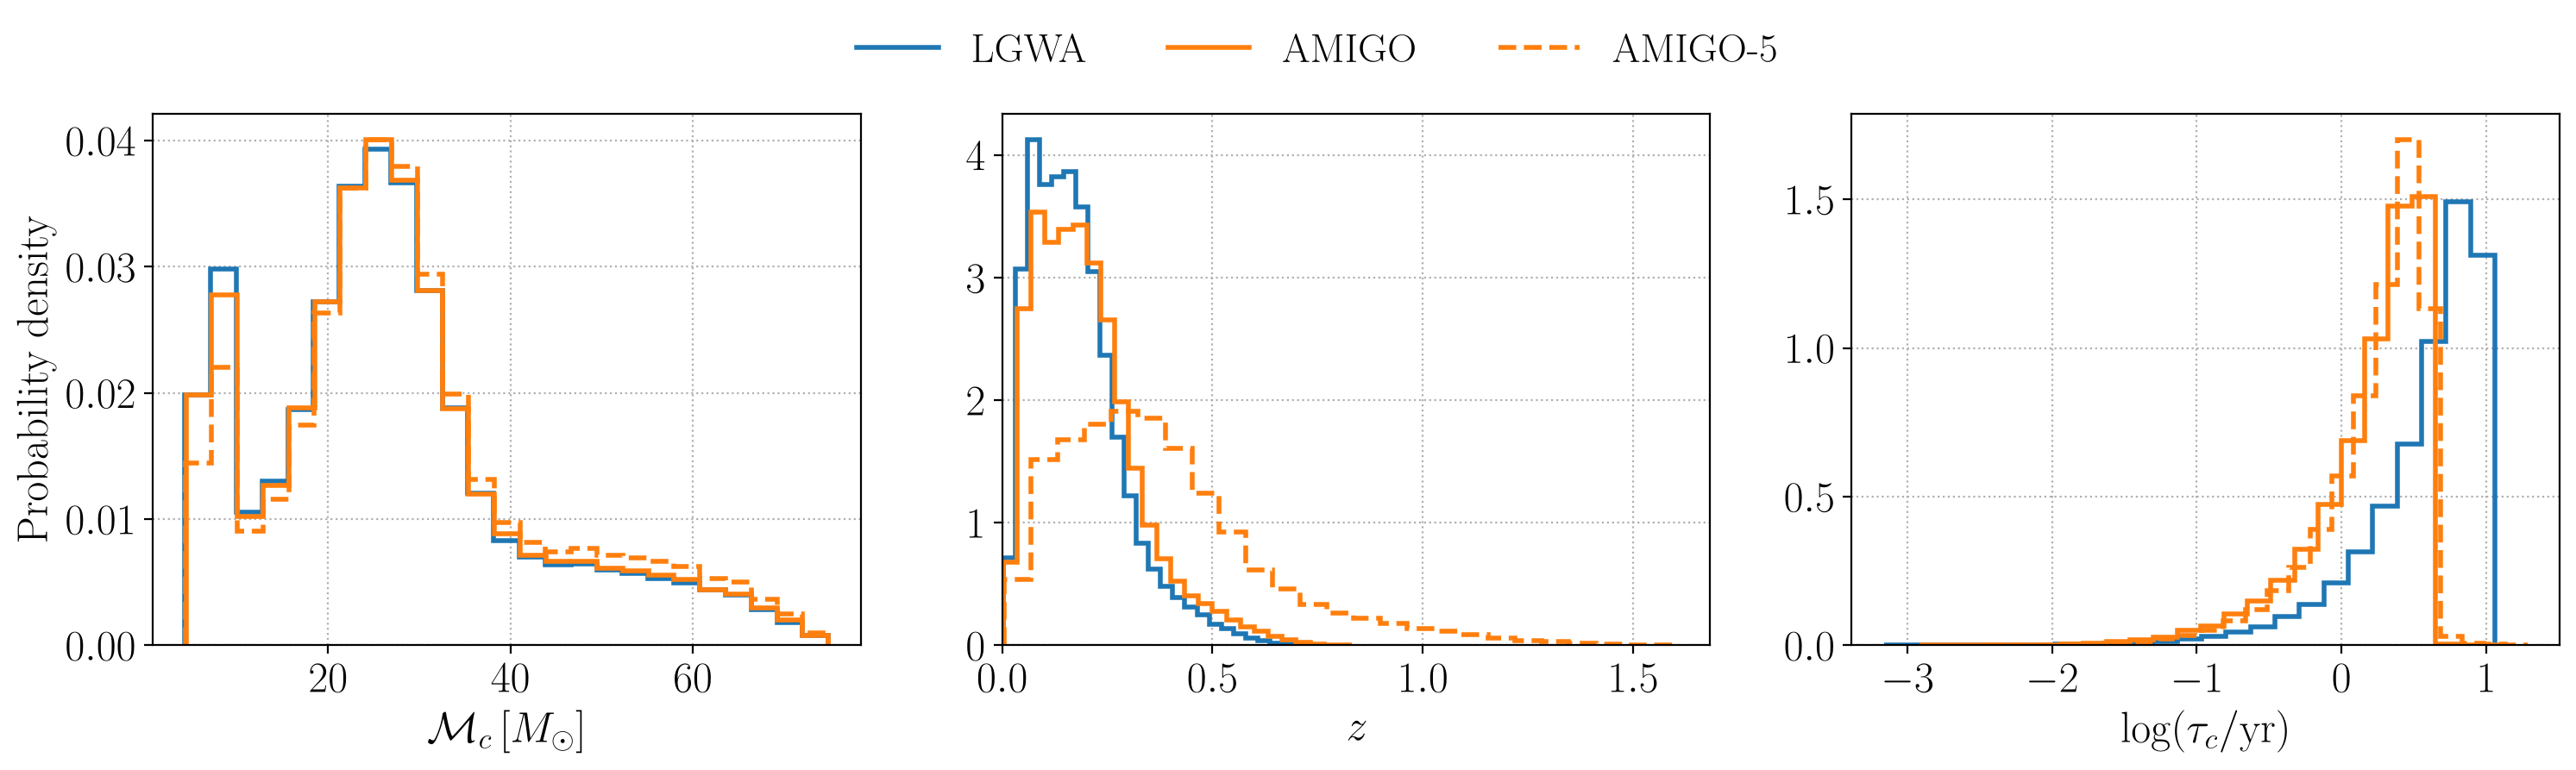

In [19]:
from matplotlib.lines import Line2D
plt.rcParams.update({"font.size": 18})
bins = 25

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(lgwa_samples[:,0],bins=bins,histtype='step',density=True,lw=2)
ax[0].hist(amigo_samples[:,0],bins=bins,histtype='step',density=True,lw=2)
ax[0].hist(amigo_5_samples[:,0],bins=bins,histtype='step',density=True,lw=2, color='C1', linestyle='--')
ax[0].set_xlabel(r'$\mathcal{M}_c\,[M_\odot]$')
ax[0].set_ylabel('Probability density')

ax[1].hist(lgwa_samples[:,2],bins=bins,histtype='step',density=True,lw=2)
ax[1].hist(amigo_samples[:,2],bins=bins,histtype='step',density=True,lw=2)
ax[1].hist(amigo_5_samples[:,2],bins=bins,histtype='step',density=True,lw=2, color='C1', linestyle='--')
ax[1].set_xlabel(r'$z$')
ax[1].set_xlim(0)

ax[2].hist(lgwa_samples[:,3],bins=bins,histtype='step',density=True,lw=2)
ax[2].hist(amigo_samples[:,3],bins=bins,histtype='step',density=True,lw=2)
ax[2].hist(amigo_5_samples[:,3],bins=bins,histtype='step',density=True,lw=2, color='C1', linestyle='--')
ax[2].set_xlabel(r'$\log (\tau_c/\mathrm{yr})$')

legend_elements = [Line2D([0], [0], color='C0', lw=2, label='LGWA'),
                   Line2D([0], [0], color='C1', lw=2, label='AMIGO'),
                   Line2D([0], [0], color='C1', linestyle='--', lw=2, label='AMIGO-5')]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=17, frameon=False, bbox_to_anchor=(0.5, 1.05))
plt.savefig('../plots/lgwa_amigo_comparison.png', dpi=600, bbox_inches='tight')

In [24]:
sample_dir = Path('lgwa_event_snr')
sample_pattern = '*_samples_full.txt'
lgwa_samples_full, sample_files, sample_counts = load_sample_directory(sample_dir, sample_pattern)

lgwa_samples_full[:,3] = np.log10(lgwa_samples_full[:,3])  # log t_merger
lgwa_samples_full[:,0] = np.log10(lgwa_samples_full[:,0])  # log t_merger

print(sample_counts, len(lgwa_samples_full[:,0]))

[1848, 1846, 1720, 1810, 1713] 8937


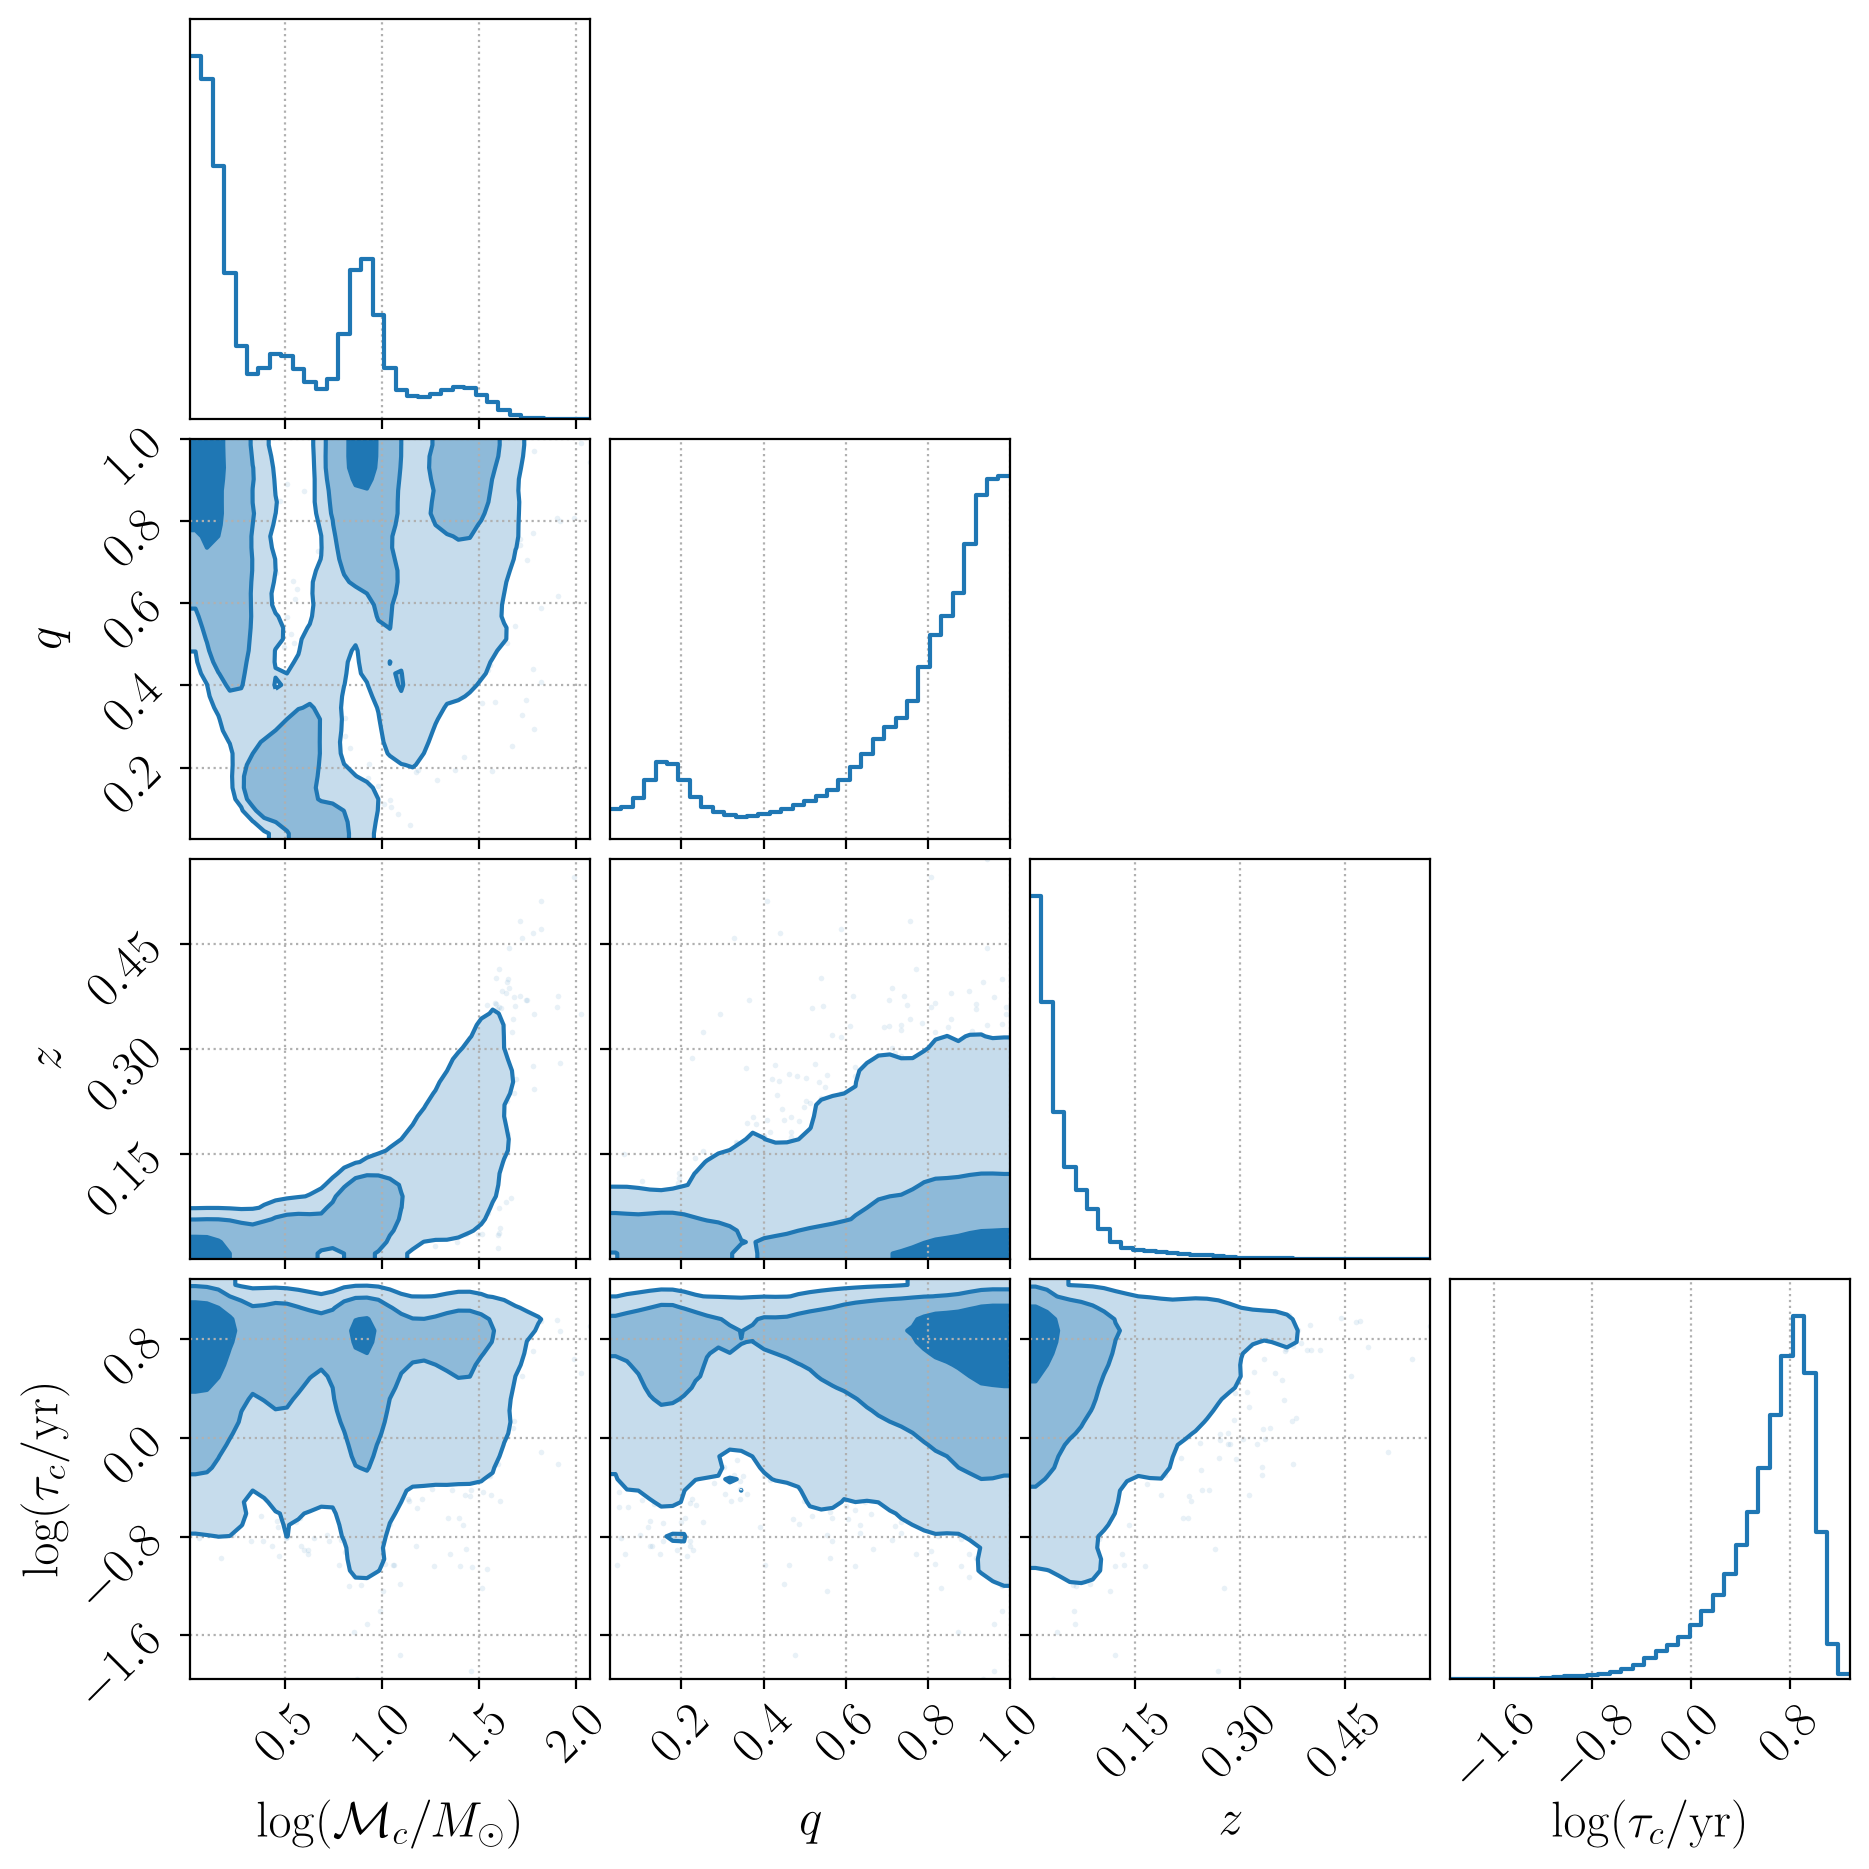

In [25]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\log (\mathcal{M}_c/M_\odot)$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    lgwa_samples_full,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
# figure.suptitle('LGWA-detectable samples full', y=0.995)
figure.savefig('../plots/lgwa_event_count_samples_full_corner.png', dpi=220, bbox_inches='tight')
plt.show()

In [10]:
10**np.max(lgwa_samples_full[:,3])

np.float64(19.454561506)

In [5]:
lgwa_count_samples = load_samples('lgwa_event_snr/lgwa_event_count_fullpop_madau_R0-19p0_Tobs-10p0_rho-8p0_zmax-0p8_samples.txt')

lgwa_count_samples[:,3] = np.log10(lgwa_count_samples[:,3])  # log t_merger
lgwa_count_samples[:,0] = np.log10(lgwa_count_samples[:,0])  # log t_merger


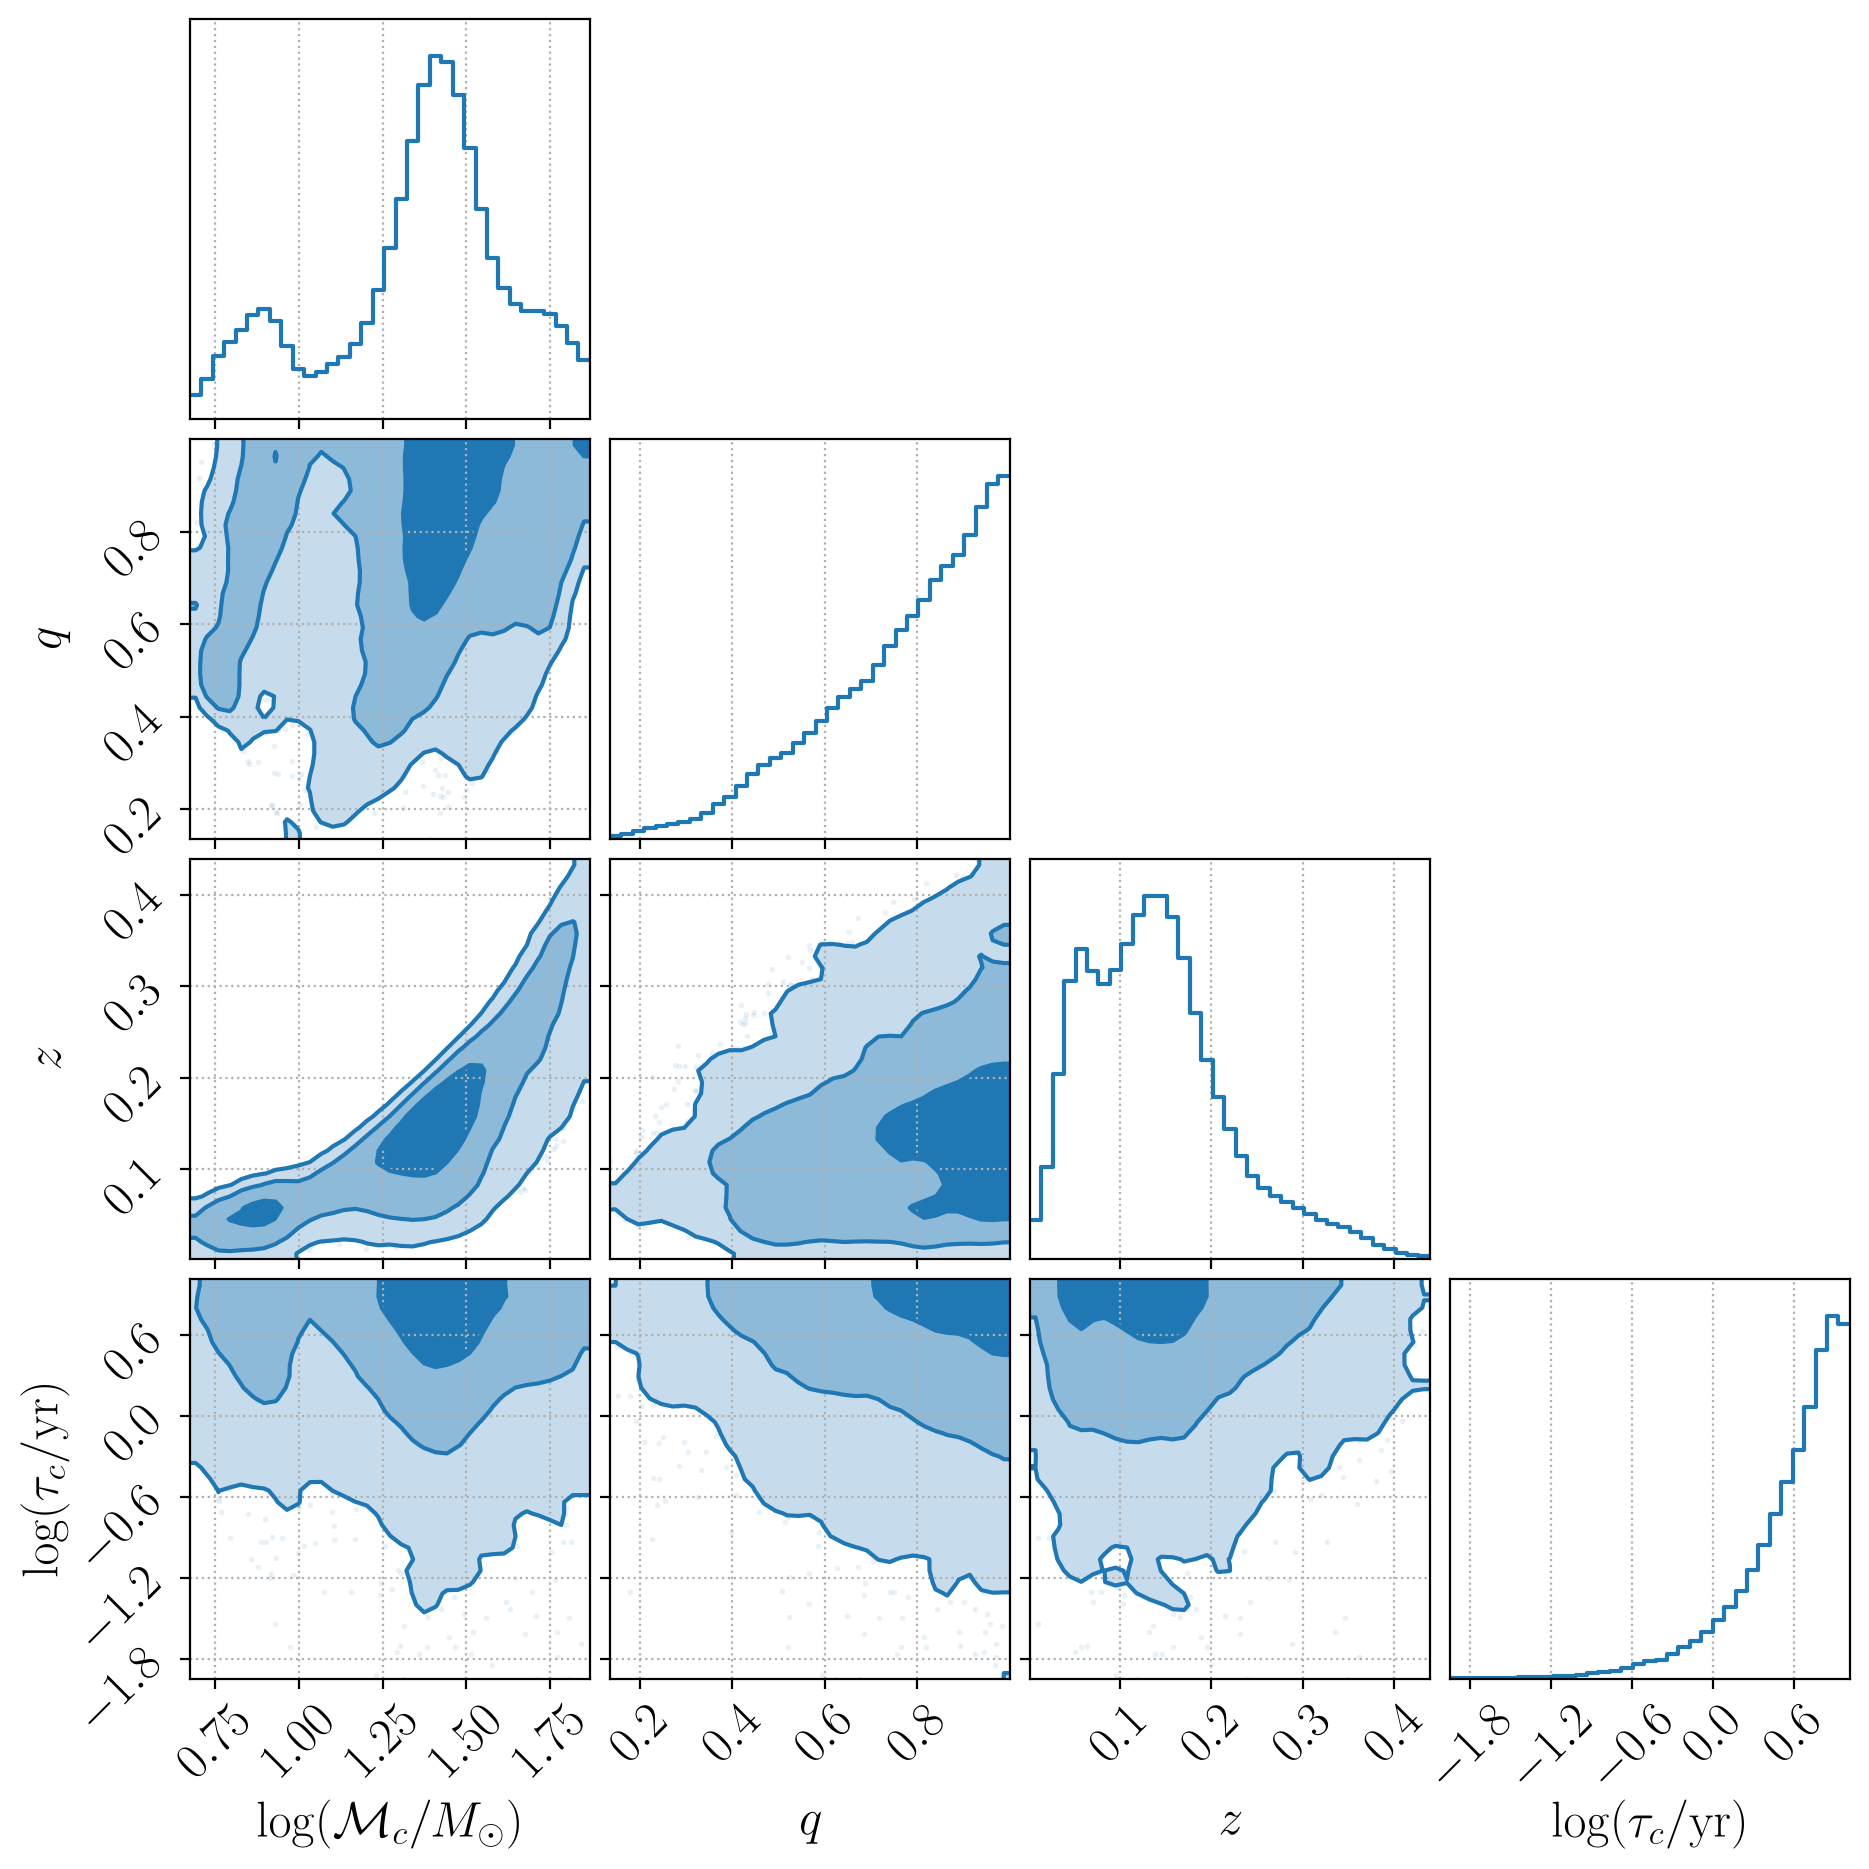

In [7]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\log (\mathcal{M}_c/M_\odot)$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    lgwa_count_samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)

In [6]:
lgwa_count_samples_full = load_samples('lgwa_event_snr/lgwa_event_count_fullpop_madau_R0-130p0_Tobs-10p0_rho-8p0_zmax-0p8_samples_full.txt')

lgwa_count_samples_full[:,3] = np.log10(lgwa_count_samples_full[:,3])  # log t_merger
lgwa_count_samples_full[:,0] = np.log10(lgwa_count_samples_full[:,0])  # log t_merger


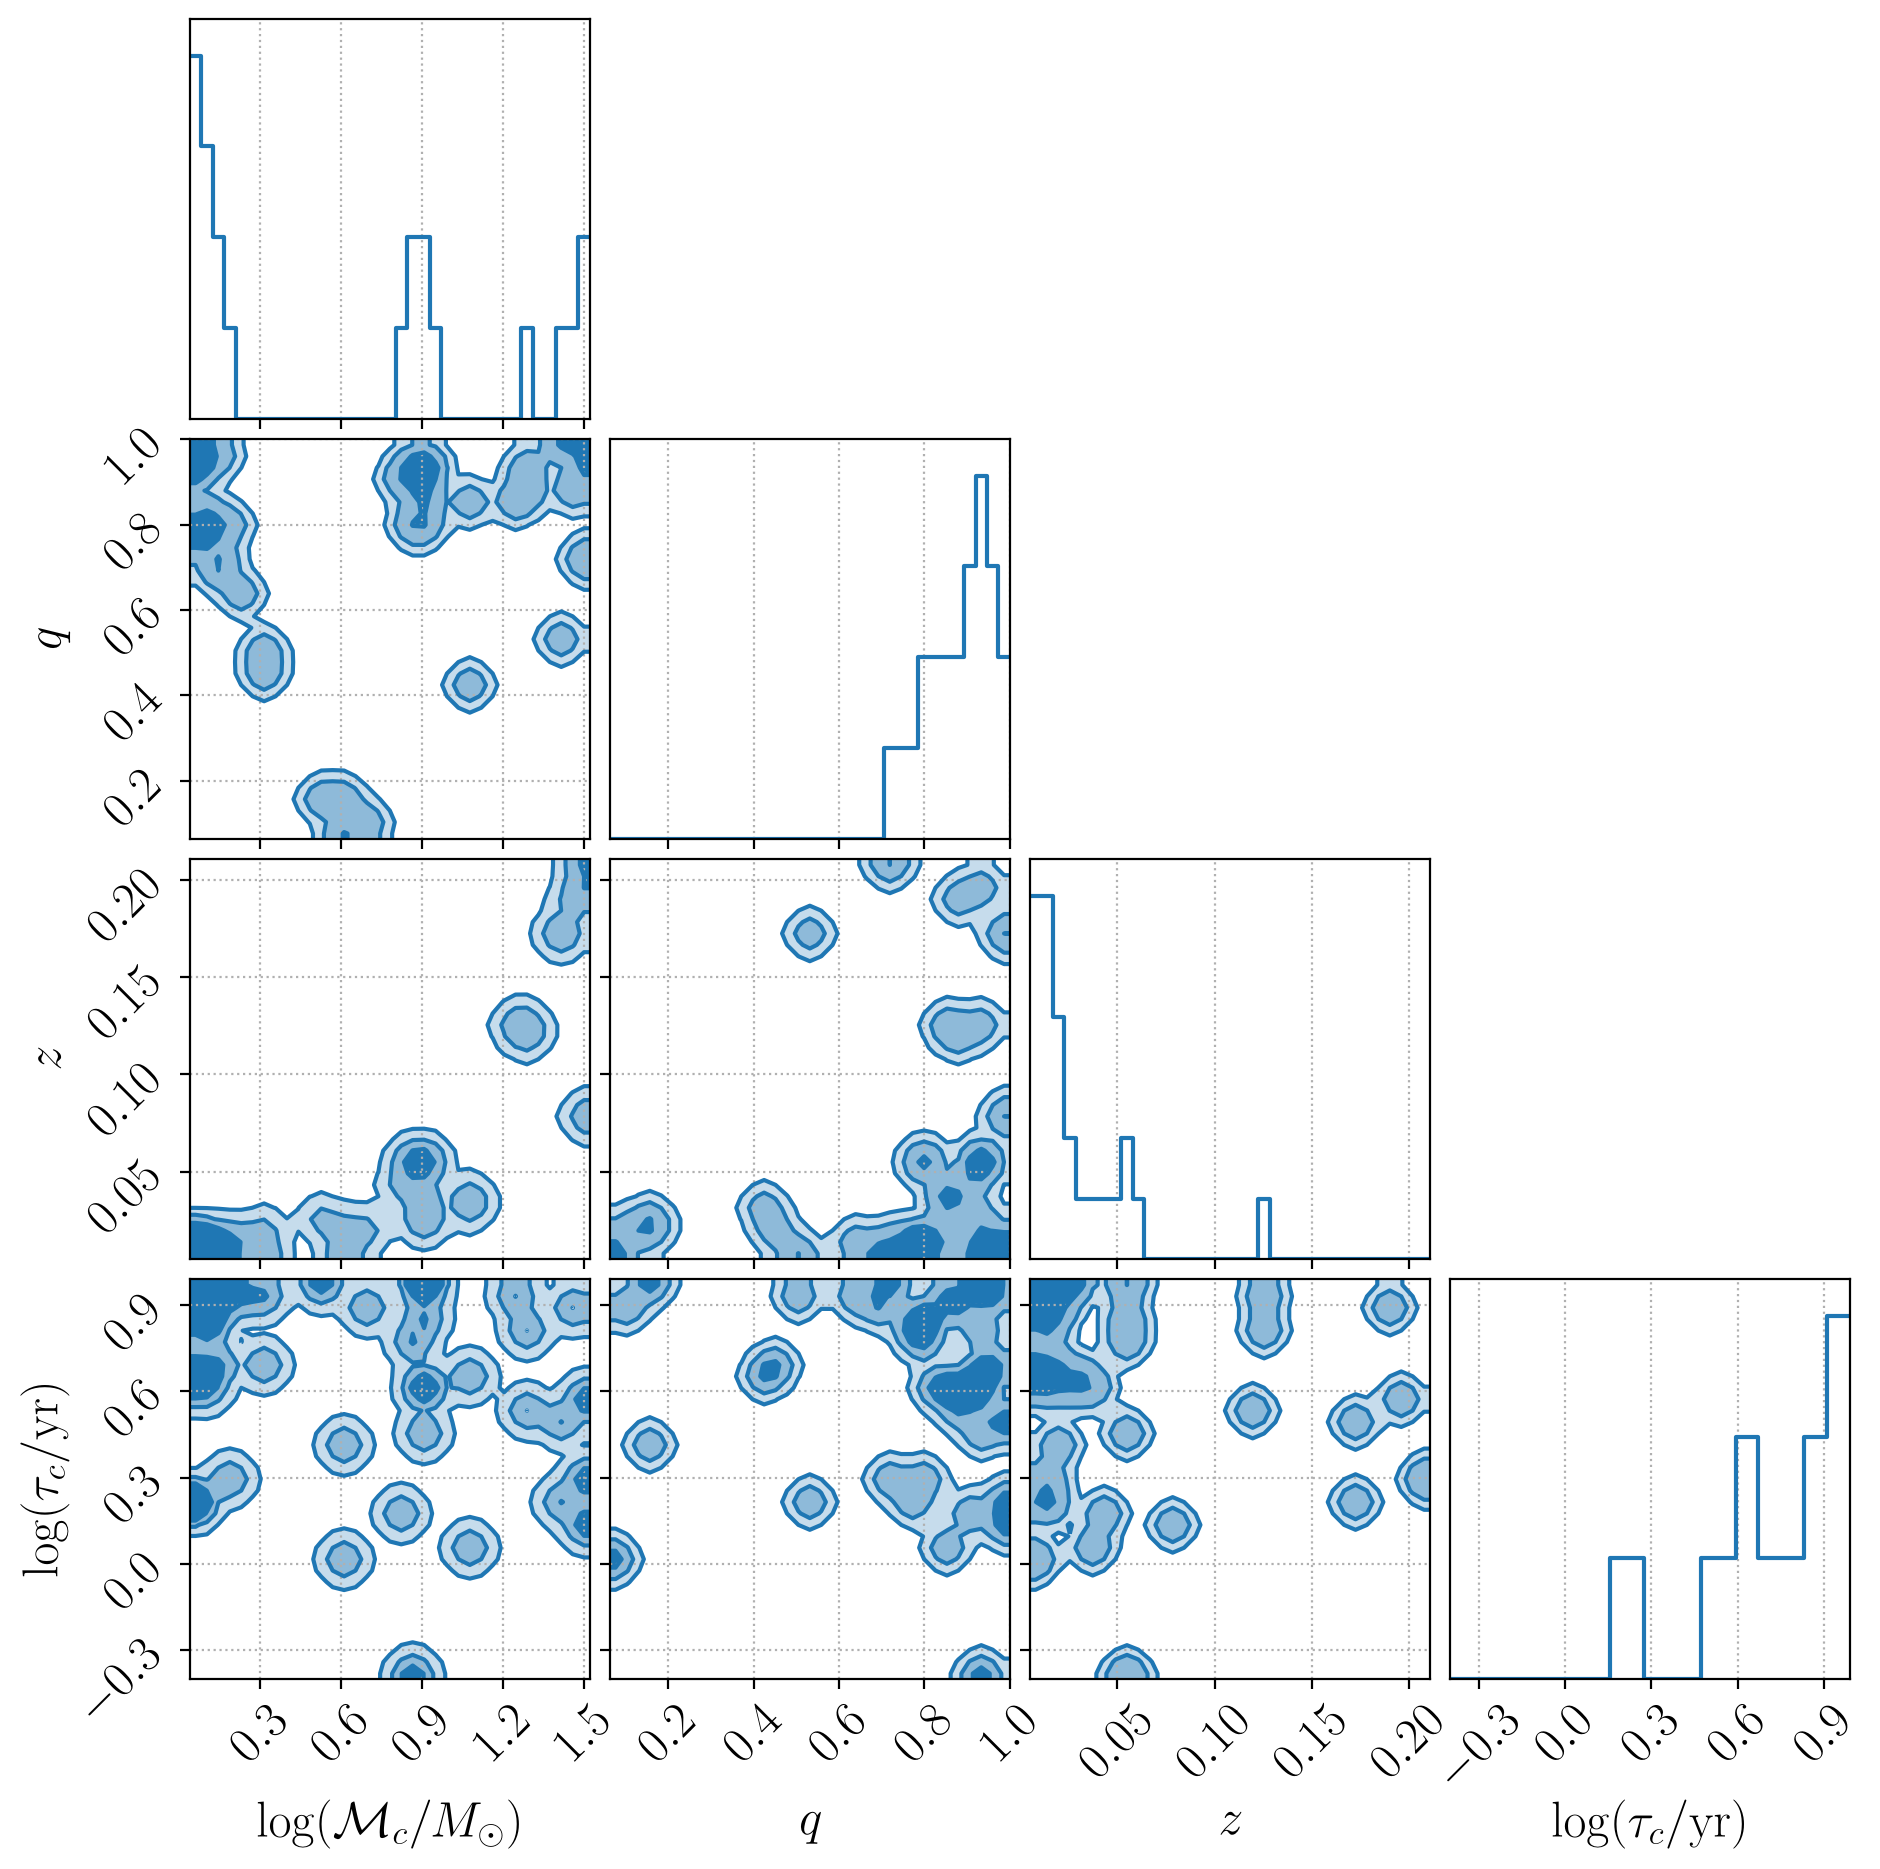

In [7]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\log (\mathcal{M}_c/M_\odot)$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$\log (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    lgwa_count_samples_full,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
# figure.suptitle('LGWA-detectable samples full', y=0.995)
figure.savefig('../plots/lgwa_event_count_samples_full_corner_.png', dpi=220, bbox_inches='tight')
plt.show()

In [ ]:
ligo_samples_full = load_samples('ligo_event_snr/ligo_event_snr_fullpop_madau_rho-8p0_zmax-3p0_seed-12345_samples_full.txt')

ligo_samples_full[:,0] = np.log10(ligo_samples_full[:,0])  # log 

In [11]:
len(ligo_samples_full[:,0])

42322

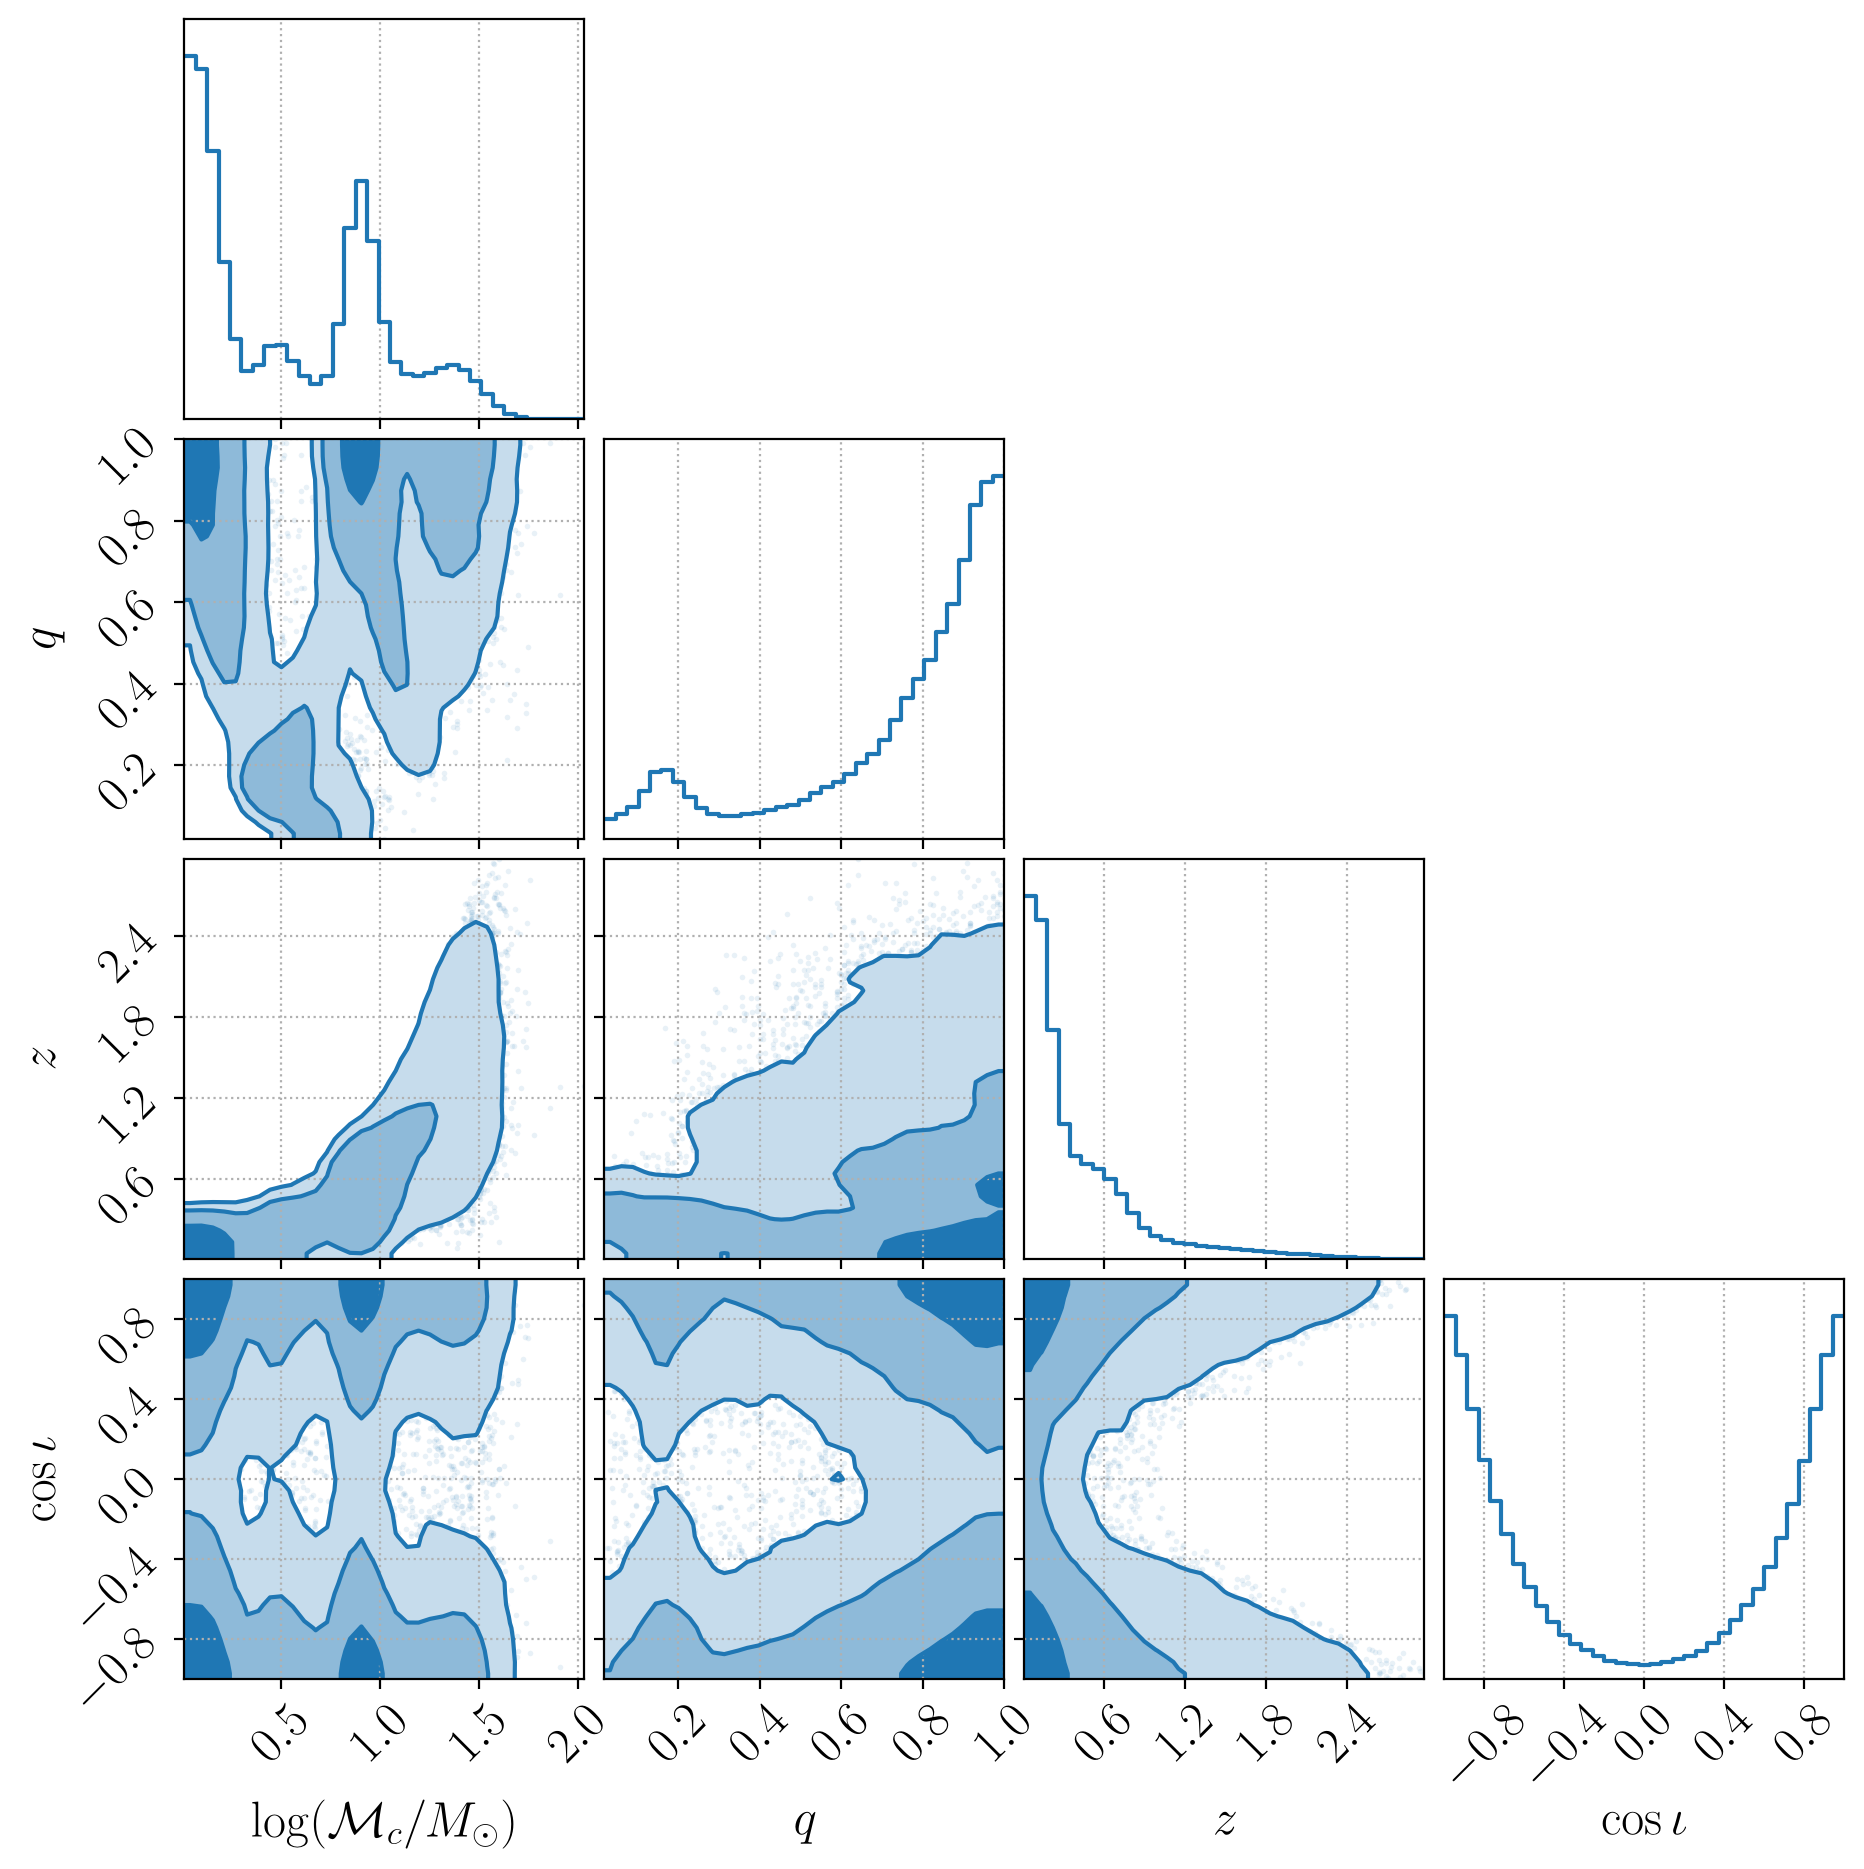

In [10]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$\log (\mathcal{M}_c/M_\odot)$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    # r'$\log (\tau_c/\mathrm{yr})$',
    r'$\cos \iota$'
]

figure = corner.corner(
    ligo_samples_full,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)
# figure.suptitle('LGWA-detectable samples full', y=0.995)
figure.savefig('../plots/ligo_event_count_samples_full_corner.png', dpi=220, bbox_inches='tight')
plt.show()

In [18]:
lisa_taiji_tianqin_samples = load_samples('space_event_count_lgwa/space_event_count_lgwa_fullband_detected_lisa_taiji_tianqin_fullpop_madau_R0-19p0_Tobs-4p0_Tdelay-list-14_-10p0-to-20p0_rho-8p0_zmax-1p0_samples.txt')



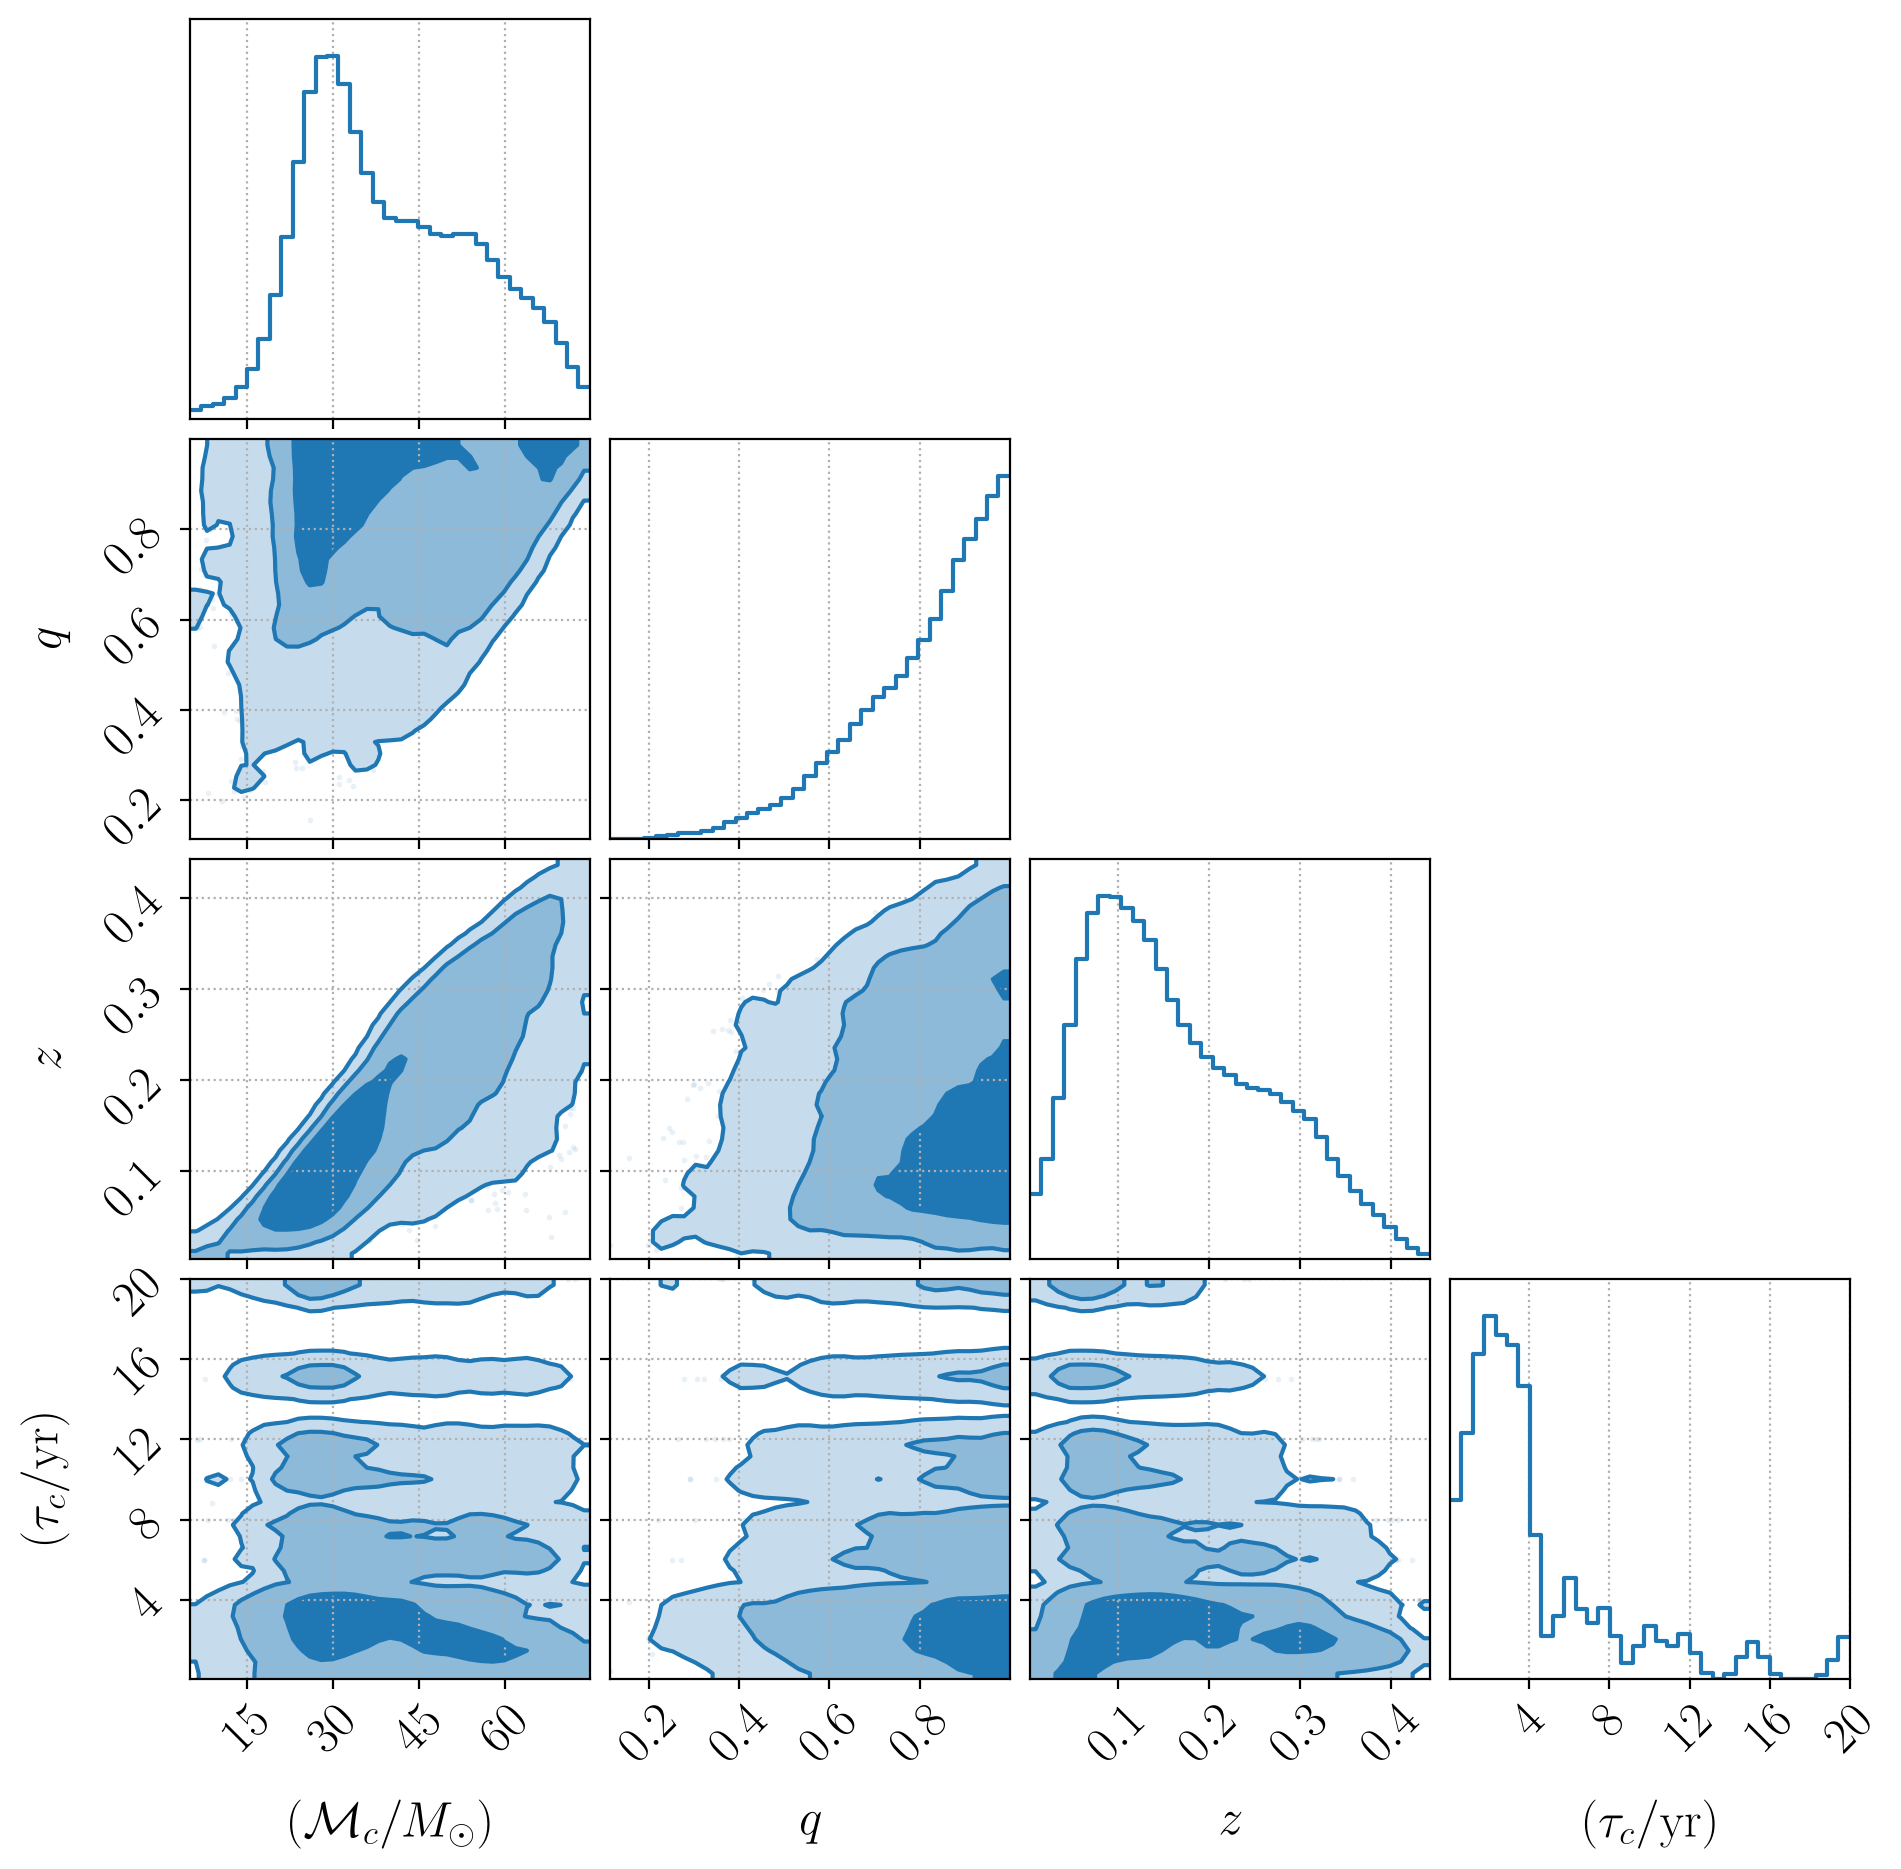

In [19]:
plt.rcParams.update({"font.size": 18})

labels = [
    r'$ (\mathcal{M}_c/M_\odot)$',
    r'$q$',
    r'$z$',
    # r'$\log t_\mathrm{merger}\,[\mathrm{yr}]$',
    r'$ (\tau_c/\mathrm{yr})$',
]

figure = corner.corner(
    lisa_taiji_tianqin_samples,
    labels=labels,
    bins=bins,
    color='tab:blue',
    # show_titles=True,
    title_fmt='.3g',
    # quantiles=[0.16, 0.5, 0.84],
    smooth=1.0,
    smooth1d=1.0,
    plot_datapoints=True,
    fill_contours=True,
    levels=(0.393, 0.865, 0.989),
)

In [13]:
lisa_taiji_tianqin_samples[:,3]

array([ 0.9102835 ,  0.89290877,  2.09189804, ..., 20.        ,
       20.        , 20.        ], shape=(4663,))